In [1]:
import os, sys, time, warnings, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, time, warnings
import numpy as np
from sklearn.metrics import roc_auc_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

N_TRIALS  = 30          
TUNE_SEED = 42     

OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
SAVE_DIR   = f'{OUTPUT_DIR}/saved_models'


print("python  :", sys.version)
print("platform:", platform.platform())
print("numpy   :", np.__version__)
print("pandas  :", pd.__version__)


python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
platform: Linux-6.12.90+-x86_64-with-glibc2.35
numpy   : 2.0.2
pandas  : 2.3.3


In [2]:
import torch, gc
torch.cuda.empty_cache()
gc.collect()
torch.cuda.synchronize()

In [3]:
import torch
import optuna
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report,
)
from category_encoders import WOEEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier 


from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder, QuantileTransformer

optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Imports OK')


Imports OK


In [4]:
!pip install pytorch_tabnet 
from pytorch_tabnet.tab_model import TabNetClassifier
print('pytorch_tabnet OK')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.5 MB/s eta 0:00:00
pytorch_tabnet OK


In [5]:
!pip install tabm --break-system-packages -q
import tabm

In [6]:
!pip install entmax

# A - FUNCTION

In [7]:
def evaluate(model, X, y_true, label='', threshold=None):
    y_prob = model.predict_proba(X)[:, 1]
    y_true = np.array(y_true)
    auc    = roc_auc_score(y_true, y_prob)
    ap     = average_precision_score(y_true, y_prob)
    gini   = 2 * auc - 1
    fpr, tpr, thr_roc = roc_curve(y_true, y_prob)
    ks_scores   = tpr - fpr
    ks          = ks_scores.max()
    
    if threshold is not None:
        best_thresh = threshold
    else:
        best_thresh = float(thr_roc[ks_scores.argmax()])
    
    y_pred      = (y_prob >= best_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall_bad     = tp / (tp + fn + 1e-8)
    recall_good    = tn / (tn + fp + 1e-8)
    precision_bad  = tp / (tp + fp + 1e-8)
    f1_bad         = 2 * precision_bad * recall_bad / (precision_bad + recall_bad + 1e-8)
    if label:
        print(f"  [{label}] AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}  F1(bad)={f1_bad:.4f}")
    return dict(auc=auc, gini=gini, ks=ks, ap=ap, threshold=best_thresh,
                recall_bad=recall_bad, recall_good=recall_good,
                precision_bad=precision_bad, f1_bad=f1_bad,
                tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn))

def summarize_results(results):
    rows = []
    for name, r in results.items():
        tr, va, te = r['train'], r['valid'], r['test']
        rows.append({
            'Model'          : name,
            'Train AUC'      : round(tr['auc'],           4),
            'Valid AUC'      : round(va['auc'],           4),
            'Test AUC'       : round(te['auc'],           4),
            'Valid KS'       : round(va['ks'],            4),
            'Test Gini'      : round(te['gini'],          4),
            'Test KS'        : round(te['ks'],            4),
            'Precision (Bad)': round(te['precision_bad'], 4),
            'Recall (Bad)'   : round(te['recall_bad'],    4),
            'Recall (Good)'  : round(te['recall_good'],   4),
            'F1 (Bad)'       : round(te['f1_bad'],        4),
            'TP': int(te['tp']), 'FP': int(te['fp']),
            'TN': int(te['tn']), 'FN': int(te['fn']),
            'Threshold'      : round(te['threshold'],     4),
            'Train Time (s)' : r['train_time_s'],
        })
    return (pd.DataFrame(rows)
              .sort_values('Valid AUC', ascending=False)   # chọn model theo VALID
              .reset_index(drop=True))


def append_to_summary(df_summary, model_name, train_m, valid_m, test_m, train_time=None):
    new_row = pd.DataFrame([{
        'Model'          : model_name,
        'Train AUC'      : round(train_m['auc'],           4),
        'Valid AUC'      : round(valid_m['auc'],           4),
        'Test AUC'       : round(test_m['auc'],            4),
        'Valid KS'       : round(valid_m['ks'],            4),
        'Test Gini'      : round(test_m['gini'],           4),
        'Test KS'        : round(test_m['ks'],             4),
        'Precision (Bad)': round(test_m['precision_bad'],  4),
        'Recall (Bad)'   : round(test_m['recall_bad'],     4),
        'Recall (Good)'  : round(test_m['recall_good'],    4),
        'F1 (Bad)'       : round(test_m['f1_bad'],         4),
        'TP': int(test_m['tp']), 'FP': int(test_m['fp']),
        'TN': int(test_m['tn']), 'FN': int(test_m['fn']),
        'Threshold'      : round(test_m['threshold'],      4),
        'Train Time (s)' : train_time,
    }])
    df_summary = df_summary[df_summary['Model'] != model_name].reset_index(drop=True)
    return (pd.concat([df_summary, new_row], ignore_index=True)
              .sort_values('Valid AUC', ascending=False)
              .reset_index(drop=True))


# LƯU Ý: mọi thống kê (median, percentile, quantile, WOE, scaler) chỉ được
# FIT trên X_train, sau đó APPLY cho X_valid và X_test -> tránh data leakage.

def impute_median_group(X_train, X_valid, X_test, group_col, target_col):
    medians    = X_train.groupby(group_col, observed=True)[target_col].median()
    global_med = X_train[target_col].median()
    for df in [X_train, X_valid, X_test]:
        mask = df[target_col].isna()
        df.loc[mask, target_col] = df.loc[mask, group_col].map(medians).fillna(global_med)
    return X_train, X_valid, X_test


def impute_all_numeric(X_train, X_valid, X_test, skip_cols=None):
    skip_cols = skip_cols or []
    num_cols  = X_train.select_dtypes(include='number').columns
    for col in [c for c in num_cols if c not in skip_cols]:
        med = X_train[col].median()
        for df in [X_train, X_valid, X_test]:
            df[col] = df[col].fillna(med)
    return X_train, X_valid, X_test


def cap_iqr(X_train, X_valid, X_test, skip_cols=None, p_low=5, p_high=95):
    skip_cols = skip_cols or []
    num_cols  = X_train.select_dtypes(include='number').columns
    for col in [c for c in num_cols if c not in skip_cols]:
        data = X_train[col].dropna()
        if len(data) == 0:
            continue
        Q1, Q3 = np.percentile(data, 25), np.percentile(data, 75)
        IQR    = Q3 - Q1
        if ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).any():
            lo = np.percentile(data, p_low)
            hi = np.percentile(data, p_high)
            for df in [X_train, X_valid, X_test]:
                df[col] = df[col].clip(lo, hi)
    return X_train, X_valid, X_test
def apply_woe_scale(X_train, X_valid, X_test, y_train,
                    scale=True, drop_cols=None, verbose=True):
    """
    WOE-encode biến hạng mục + StandardScaler cho toàn bộ cột số.
    Mọi thống kê chỉ FIT trên TRAIN -> tránh data leakage.
    Trả về: X_train, X_valid, X_test, woe, scaler
    """
    X_train, X_valid, X_test = X_train.copy(), X_valid.copy(), X_test.copy()

    # 0. bỏ cột ID
    drop_cols = drop_cols if drop_cols is not None else \
                [c for c in X_train.columns if c.startswith('SK_ID')]
    for d in (X_train, X_valid, X_test):
        d.drop(columns=drop_cols, inplace=True, errors='ignore')

    # 1. WOE cho biến hạng mục (fit TRAIN)
    cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    woe = None
    if cat_cols:
        woe = WOEEncoder(cols=cat_cols, handle_unknown='value',
                         handle_missing='value', regularization=1.0)
        woe.fit(X_train[cat_cols], y_train)
        for d in (X_train, X_valid, X_test):
            d[cat_cols] = woe.transform(d[cat_cols])

    # 2. điền NaN còn sót bằng median TRAIN
    for c in X_train.columns:
        med = X_train[c].median()
        if pd.isna(med):
            med = 0.0
        for d in (X_train, X_valid, X_test):
            d[c] = d[c].fillna(med)

    # 3. đồng bộ thứ tự cột + ép kiểu số
    cols    = X_train.columns.tolist()
    X_valid = X_valid[cols]
    X_test  = X_test[cols]
    X_train, X_valid, X_test = (d.astype(np.float64) for d in (X_train, X_valid, X_test))

    # 4. StandardScaler (fit TRAIN) — giữ DataFrame để không mất tên cột
    scaler = None
    if scale:
        scaler = StandardScaler().fit(X_train)
        X_train = pd.DataFrame(scaler.transform(X_train), columns=cols, index=X_train.index)
        X_valid = pd.DataFrame(scaler.transform(X_valid), columns=cols, index=X_valid.index)
        X_test  = pd.DataFrame(scaler.transform(X_test),  columns=cols, index=X_test.index)

    if verbose:
        print(f'  WOE cols={len(cat_cols)} | drop={list(drop_cols)} | shape train={X_train.shape}')
    return X_train, X_valid, X_test, woe, scaler

def preprocess_for_tabnet_v3(X_train, X_valid, X_test, y_train,
                             max_card=20, verbose=True):
    X_train, X_valid, X_test = X_train.copy(), X_valid.copy(), X_test.copy()

    # ── 1. WOE: mỗi biến hạng mục -> 1 cột số (fit TRAIN) ────────────────
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    woe = None
    if cat_cols:
        woe = WOEEncoder(cols=cat_cols, handle_unknown='value',
                         handle_missing='value', regularization=1.0)
        woe.fit(X_train[cat_cols], y_train)
        for d in (X_train, X_valid, X_test):
            d[cat_cols] = woe.transform(d[cat_cols])

    # ── 2. giờ mọi cột đều là số -> tách cont / low_card ─────────────────
    num_all  = X_train.select_dtypes(include='number').columns.tolist()
    low_card = [c for c in num_all if X_train[c].nunique(dropna=True) <= max_card]
    cont     = [c for c in num_all if c not in low_card]   # WOE cols nằm ở đây

    for c in cont:
        med = X_train[c].median()
        for d in (X_train, X_valid, X_test): d[c] = d[c].fillna(med)
    for c in low_card:
        for d in (X_train, X_valid, X_test): d[c] = d[c].fillna(0)

    qt = QuantileTransformer(output_distribution='normal',
                             n_quantiles=min(1000, len(X_train)), random_state=42)
    qt.fit(X_train[cont])

    out = {}
    for nm, d in [('tr', X_train), ('va', X_valid), ('te', X_test)]:
        blk = pd.DataFrame(qt.transform(d[cont]), columns=cont,
                           index=d.index).clip(-5, 5).astype(np.float32)
        out[nm] = pd.concat([blk, d[low_card].astype(np.float32)], axis=1)

    if verbose:
        print(f'  cont(+WOE)={len(cont)} | low_card={len(low_card)} | '
              f'shape train={out["tr"].shape}')
    return out['tr'], out['va'], out['te'], qt, woe, len(cont)

In [8]:
def train_baseline_models(models, X_tr, X_va, X_te, y_tr, y_va, y_te):
    """Fit trên TRAIN.
    - Ngưỡng cut-off (threshold) chọn trên VALID (KS max).
    - TEST chỉ dùng để báo cáo, áp đúng ngưỡng đã chọn từ VALID.
    """
    results = {}

    for name, model in models.items():
        print('Training model ' , {name})
        t0 = time.time()
    
        if name == 'XGBoost':
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                verbose=False,
            )
        elif name == 'LightGBM':
            from lightgbm import early_stopping, log_evaluation
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                eval_metric='auc',
                callbacks=[early_stopping(100), log_evaluation(0)],
            )
        elif name == 'CatBoost':
            model.fit(
                X_tr, y_tr,
                eval_set=(X_va, y_va),
                early_stopping_rounds=50,
                verbose=False,
            )
        else:  # Logistic Regression, MLP
            model.fit(X_tr, y_tr)
    
        elapsed = time.time() - t0
        print(f'({elapsed:.1f}s)')

        y_te_np = y_te.values if hasattr(y_te, 'values') else np.array(y_te)

        va_m  = evaluate(model, X_va, y_va, label='valid')          # tự tìm threshold
        thr   = va_m['threshold']
        tr_m  = evaluate(model, X_tr, y_tr, label='train', threshold=thr)
        te_m  = evaluate(model, X_te, y_te, label='test',  threshold=thr)

        results[name] = {
            'model'       : model,
            'train'       : tr_m,
            'valid'       : va_m,
            'test'        : te_m,
            'train_time_s': round(elapsed, 2),
            'y_true'      : y_te_np,
            'y_prob'      : model.predict_proba(X_te)[:, 1],
            'y_true_valid': y_va.values if hasattr(y_va, 'values') else np.array(y_va),
            'y_prob_valid': model.predict_proba(X_va)[:, 1],
            'auc'         : te_m['auc'],
        }
    return results


def build_baseline_models(bad_weight, best=None, n_samples=10000):
    """Nếu best=None → dùng tham số mặc định (như cũ).
       Nếu truyền best (từ Optuna) → nhồi tham số đã tune vào từng model."""
    best = best or {}
    min_leaf = max(20, n_samples // 2000)

    def bp(name):                     # lấy params đã tune cho 1 model (rỗng nếu chưa có)
        return best.get(name, {})

    return {
        'Logistic Regression': LogisticRegression(
            random_state=42, max_iter=3000, solver="lbfgs",
            **bp('LogisticRegression')),          # C, class_weight

        'LightGBM': LGBMClassifier(
            n_estimators=3000, subsample_freq=1,
            random_state=42, n_jobs=-1, verbose=-1,
            **bp('LightGBM')),                    # learning_rate, num_leaves, ...

        'XGBoost': XGBClassifier(
            n_estimators=3000, tree_method="hist", eval_metric='auc',
            early_stopping_rounds=50, random_state=42, n_jobs=-1,
            **bp('XGBoost')),                     # learning_rate, max_depth, ...

        'CatBoost': CatBoostClassifier(
            iterations=3000, eval_metric="AUC",
            random_seed=42, verbose=0,
            **bp('CatBoost')),                    # learning_rate, depth, l2_leaf_reg, ...

        'MLP': MLPClassifier(
            solver='adam', max_iter=200, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15, random_state=42,
            **_mlp_params(bp('MLP'))),            # hidden/alpha/lr_init/activation
    }


def _mlp_params(p):
    """Optuna lưu MLP dạng {'hidden':'128,64','alpha':..,'lr_init':..,'activation':..}
       → đổi sang đúng tên tham số của MLPClassifier."""
    if not p:
        return dict(hidden_layer_sizes=(64, 32), alpha=1e-2, learning_rate_init=1e-3, activation='relu')
    return dict(
        hidden_layer_sizes = tuple(int(x) for x in p['hidden'].split(',')),
        alpha              = p['alpha'],
        learning_rate_init = p['lr_init'],
        activation         = p['activation'])

In [9]:
class TabMWrapper:
    """predict_proba tương thích evaluate(): trung bình sigmoid trên k submodel."""
    def __init__(self, model, device, bs=4096):
        self.model, self.device, self.bs = model, device, bs
    def _logits(self, X):
        if hasattr(X, 'values'): X = X.values
        X = X.astype(np.float32); self.model.eval(); out = []
        with torch.no_grad():
            for s in range(0, len(X), self.bs):
                xb = torch.tensor(X[s:s+self.bs]).to(self.device)
                out.append(self.model(xb, None).squeeze(-1).cpu().numpy())  # (B,k,1)->(B,k)
        return np.concatenate(out, 0)
    def predict_proba(self, X):
        p = torch.sigmoid(torch.tensor(self._logits(X))).mean(1).numpy()
        return np.column_stack([1-p, p])
    def predict_with_uncertainty(self, X):        # dùng nếu muốn so bất định với Proposed
        P = torch.sigmoid(torch.tensor(self._logits(X))).numpy()
        return P.mean(1), P.std(1)
        
def train_tabm_lib(X_tr, X_va, X_te, y_tr, y_va, y_te, bad_weight,
                   k=8, d_block=256, n_blocks=3, arch_type='tabm',
                   lr=1e-3, weight_decay=1e-5, batch_size=512, dropout=0.1,
                   max_epochs=40, patience=10, warmup_epochs=2, seed=42,
                   verbose_every=10**9, **_ignore):
    dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.manual_seed(seed); np.random.seed(seed)
    to = lambda z, dt: z.values.astype(dt) if hasattr(z, 'values') else np.asarray(z, dtype=dt)
    Xtr = torch.tensor(to(X_tr, np.float32)); ytr = torch.tensor(to(y_tr, np.float32))
    Xva = torch.tensor(to(X_va, np.float32)); yva = torch.tensor(to(y_va, np.float32))
    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([bad_weight]).to(dev))
    dl = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True, drop_last=True)

    model = tabm.TabM.make(n_num_features=Xtr.shape[1], cat_cardinalities=None,
                           d_out=1, num_embeddings=None,           # TabM chuẩn, không PLR
                           k=k, d_block=d_block, n_blocks=n_blocks,
                           dropout=dropout, arch_type=arch_type).to(dev)
    if verbose_every < 1000:
        print(f'  [TabM] k={k} | d_block={d_block} | params={sum(p.numel() for p in model.parameters()):,}')
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sch = (SequentialLR(opt, [LinearLR(opt, 0.1, 1.0, warmup_epochs),
             CosineAnnealingLR(opt, T_max=max_epochs-warmup_epochs, eta_min=1e-6)],
             milestones=[warmup_epochs]) if warmup_epochs > 0
           else CosineAnnealingLR(opt, T_max=max_epochs, eta_min=1e-6))

    best, best_state, no_imp = 0.0, None, 0; t0 = time.time()
    for ep in range(max_epochs):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(dev), yb.to(dev); opt.zero_grad()
            out = model(xb, None).squeeze(-1)                       # (B,k)
            crit(out, yb.unsqueeze(1).expand_as(out)).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        sch.step()
        model.eval()
        with torch.no_grad():
            pv = torch.sigmoid(model(Xva.to(dev), None).squeeze(-1)).mean(1).cpu().numpy()
        auc = roc_auc_score(yva.numpy(), pv)
        if auc > best + 1e-5:
            best, no_imp = auc, 0
            best_state = {kk: v.cpu().clone() for kk, v in model.state_dict().items()}
        else:
            no_imp += 1
            if no_imp >= patience: break
    elapsed = time.time() - t0
    model.load_state_dict(best_state); model.to(dev)
    w = TabMWrapper(model, dev)
    va = evaluate(w, to(X_va, np.float32), to(y_va, np.int64), label='valid'); thr = va['threshold']
    tr = evaluate(w, to(X_tr, np.float32), to(y_tr, np.int64), label='train', threshold=thr)
    te = evaluate(w, to(X_te, np.float32), to(y_te, np.int64), label='test',  threshold=thr)
    print(f'  [TabM] Done {time.time()-t0:.1f}s | Test AUC={te["auc"]:.4f}')
    return w, tr, va, te, model, dev, elapsed

In [10]:
TUNE_SEED = 42        

def run_study(name, objective, n_trials):
    """Runner CHUNG — mọi model đi qua đây để đảm bảo NGÂN SÁCH & sampler như nhau."""
    import time, optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    t0 = time.time()
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=TUNE_SEED))
    study.optimize(objective, n_trials=n_trials)
    print(f"[{name:18s}] best valid AUC = {study.best_value:.4f}  "
          f"({time.time()-t0:.0f}s, {n_trials} trials)")
    return {"best_valid_auc": round(study.best_value, 4), "params": study.best_params}

# ── GBDT & LR: dùng ma trận WOE (X_train_bl / X_valid_bl) ─────────────────────
def objective_xgb(trial):
    import xgboost as xgb
    from sklearn.metrics import roc_auc_score
    m = xgb.XGBClassifier(
        n_estimators=3000,
        learning_rate    = trial.suggest_float("learning_rate", 1e-2, 3e-1, log=True),
        max_depth        = trial.suggest_int("max_depth", 3, 9),
        min_child_weight = trial.suggest_float("min_child_weight", 1.0, 20.0),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        scale_pos_weight = float(bad_w), tree_method="hist", eval_metric="auc",
        early_stopping_rounds=50, random_state=TUNE_SEED, n_jobs=-1)
    m.fit(X_train_bl, y_train, eval_set=[(X_valid_bl, y_valid)], verbose=False)
    return roc_auc_score(y_valid, m.predict_proba(X_valid_bl)[:, 1])

def objective_lgbm(trial):
    import lightgbm as lgb
    from sklearn.metrics import roc_auc_score
    spw = trial.suggest_categorical("scale_pos_weight", [1.0, float(bad_w)])  # ← để tuner chọn
    m = lgb.LGBMClassifier(
        n_estimators=3000,
        learning_rate     = trial.suggest_float("learning_rate", 1e-2, 3e-1, log=True),
        num_leaves        = trial.suggest_int("num_leaves", 15, 255),
        min_child_samples = trial.suggest_int("min_child_samples", 10, 200),
        subsample         = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        scale_pos_weight  = spw, subsample_freq=1,
        random_state=TUNE_SEED, n_jobs=-1, verbose=-1)
    m.fit(X_train_bl, y_train, eval_set=[(X_valid_bl, y_valid)], eval_metric="auc",
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
    return roc_auc_score(y_valid, m.predict_proba(X_valid_bl)[:, 1])

def objective_cat(trial):
    import catboost as cb
    from sklearn.metrics import roc_auc_score
    m = cb.CatBoostClassifier(
        iterations=3000,
        learning_rate   = trial.suggest_float("learning_rate", 1e-2, 3e-1, log=True),
        depth           = trial.suggest_int("depth", 4, 10),
        l2_leaf_reg     = trial.suggest_float("l2_leaf_reg", 1.0, 30.0, log=True),
        random_strength = trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        scale_pos_weight= float(bad_w), eval_metric="AUC",
        random_seed=TUNE_SEED, verbose=0)
    m.fit(X_train_bl, y_train, eval_set=(X_valid_bl, y_valid),
          early_stopping_rounds=50, verbose=0)
    return roc_auc_score(y_valid, m.predict_proba(X_valid_bl)[:, 1])

def objective_lr(trial):
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score
    m = LogisticRegression(
        C            = trial.suggest_float("C", 1e-3, 1e2, log=True),
        class_weight = trial.suggest_categorical("class_weight", [None, "balanced"]),
        max_iter=3000, solver="lbfgs")
    m.fit(X_train_bl, y_train)
    return roc_auc_score(y_valid, m.predict_proba(X_valid_bl)[:, 1])

# ── Họ NN: dùng ma trận QuantileTransformer (X_fe_tr_np / X_fe_va_np) ─────────
def objective_mlp(trial):
    from sklearn.neural_network import MLPClassifier
    from sklearn.metrics import roc_auc_score
    hidden = trial.suggest_categorical("hidden", ["128", "256", "128,64", "256,128"])
    m = MLPClassifier(
        hidden_layer_sizes = tuple(int(x) for x in hidden.split(",")),
        alpha              = trial.suggest_float("alpha", 1e-6, 1e-2, log=True),
        learning_rate_init = trial.suggest_float("lr_init", 1e-4, 5e-3, log=True),
        activation         = trial.suggest_categorical("activation", ["relu", "tanh"]),
        max_iter=200, early_stopping=True, n_iter_no_change=15, random_state=TUNE_SEED)
    m.fit(X_fe_tr_np, y_train)
    return roc_auc_score(y_valid, m.predict_proba(X_fe_va_np)[:, 1])

def objective_tabnet(trial):
    # TabNet GỐC (pytorch-tabnet) — độc lập với ImpTabNet. Dùng chung X_fe_* (QT).
    from pytorch_tabnet.tab_model import TabNetClassifier
    from sklearn.metrics import roc_auc_score
    import numpy as np, torch

    nda = trial.suggest_int("n_da", 16, 64, step=16)     # TabNet gốc để n_d = n_a
    clf = TabNetClassifier(
        n_d=nda, n_a=nda,
        n_steps       = trial.suggest_int("n_steps", 3, 7),
        gamma         = trial.suggest_float("gamma", 1.0, 2.0),
        lambda_sparse = trial.suggest_float("lambda_sparse", 1e-5, 1e-2, log=True),
        optimizer_params = dict(lr=trial.suggest_float("lr", 5e-3, 3e-2, log=True)),
        seed=TUNE_SEED, verbose=0, device_name="auto")
    clf.fit(
        X_fe_tr_np, np.asarray(y_train).ravel().astype(int),
        eval_set=[(X_fe_va_np, np.asarray(y_valid).ravel().astype(int))],
        eval_metric=["auc"],
        max_epochs=60, patience=12, batch_size=2048, virtual_batch_size=128,
        weights=1)                    # weights=1 = cân bằng lớp khi lấy mẫu
    return roc_auc_score(np.asarray(y_valid).ravel(), clf.predict_proba(X_fe_va_np)[:, 1])

def objective_tabm(trial):
    params = dict(
        k            = trial.suggest_categorical("k", [8, 16, 32]),
        d_block      = trial.suggest_int("d_block", 128, 512, step=64),
        n_blocks     = trial.suggest_int("n_blocks", 2, 4),
        dropout      = trial.suggest_float("dropout", 0.0, 0.3),
        lr           = trial.suggest_float("lr", 1e-3, 1e-2, log=True),
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True))
    _, _, va_m, *_ = train_tabm_lib(
        X_fe_tr_np, X_fe_va_np, X_fe_va_np,       # X_te = valid → KHÔNG đụng test
        y_train, y_valid, y_valid, bad_w,
        seed=TUNE_SEED, max_epochs=40, patience=8, warmup_epochs=2,
        verbose_every=10**9, **params)
    return va_m['auc']

In [11]:
import json

def load_best_params(*paths):
    """Đọc 1 hoặc NHIỀU file Optuna → GỘP thành {tên_model: {param: value}}.
       File sau ghi đè file trước nếu trùng tên model."""
    merged = {}
    for p in paths:
        with open(p) as f:
            blob = json.load(f)
        res = blob.get("results", blob)          # phòng khi file lưu phẳng
        for name, r in res.items():
            merged[name] = r["params"] if isinstance(r, dict) and "params" in r else r
    return merged

In [12]:
import json, os

def _defined(n):  return n in globals()

def _save_merge(new, path="best_params_baselines.json"):
    blob = {"n_trials": N_TRIALS, "tune_seed": TUNE_SEED, "results": {}}
    if os.path.exists(path):
        try: blob = json.load(open(path))
        except: pass
    blob["n_trials"], blob["tune_seed"] = N_TRIALS, TUNE_SEED
    blob.setdefault("results", {}).update(new)      # GỘP, không ghi đè nhóm cũ
    json.dump(blob, open(path, "w"), indent=2)

def run_group(studies, need):
    missing = [g for g in need if not _defined(g)]
    if missing:
        print(f"⏭  BỎ QUA {list(studies)} — chưa định nghĩa: {missing}")
        print(f"    → Chạy các cell tạo {missing} TRƯỚC rồi chạy lại cell này.\n")
        return
    out = {}
    for name, obj in studies.items():
        try:
            out[name] = run_study(name, obj, n_trials=N_TRIALS)
        except Exception as e:
            print(f"[{name:18s}] LỖI — {type(e).__name__}: {e}")
    _save_merge(out)          # lưu ngay sau mỗi nhóm

# B - DATASET

In [13]:
!pip install xlrd --quiet

In [ ]:
# ──────────────────────────────────────────
# LOAD DATA
# Link real: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients
# ──────────────────────────────────────────

path = '/kaggle/input/datasets/phmththuvn/uci-crc/default of credit card clients.xls'

# .xls -> read_excel; header thật nằm ở dòng thứ 2 (index 1)
df = pd.read_excel(path, header=1)

print(df.shape)          # kỳ vọng (30000, 25)
print(df.columns.tolist())
df.head()

(30000, 25)
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [15]:
print("Nhãn:", df.columns[-1])                    # 'default payment next month' (hoặc tương tự)
print("Phân phối nhãn:\n", df.iloc[:, -1].value_counts(normalize=True).round(3))
print("\nKiểu dữ liệu:\n", df.dtypes)

Nhãn: default payment next month
Phân phối nhãn:
 default payment next month
0    0.779
1    0.221
Name: proportion, dtype: float64

Kiểu dữ liệu:
 ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                

In [16]:
# --- Làm sạch giá trị rác (chuẩn trong tài liệu Taiwan Credit) ---
df = df.drop(columns=['ID'])
df['EDUCATION'] = df['EDUCATION'].replace({0:4, 5:4, 6:4})   # gộp giá trị lạ -> 4 (others)
df['MARRIAGE']  = df['MARRIAGE'].replace({0:3})              # 0 -> 3 (others)

TARGET = 'default payment next month'

# --- EDA cơ bản (cho phần Data trong paper) ---
print("Shape:", df.shape)
print("Trùng dòng:", df.duplicated().sum(), "| Missing:", df.isna().sum().sum())
print("Tỉ lệ nhãn:\n", df[TARGET].value_counts(normalize=True).round(3))
df.describe().T[['mean','std','min','max']].round(1)

Shape: (30000, 24)
Trùng dòng: 35 | Missing: 0
Tỉ lệ nhãn:
 default payment next month
0    0.779
1    0.221
Name: proportion, dtype: float64


,mean,std,min,max
LIMIT_BAL,167484.3,129747.7,10000.0,1000000.0
SEX,1.6,0.5,1.0,2.0
EDUCATION,1.8,0.7,1.0,4.0
MARRIAGE,1.6,0.5,1.0,3.0
AGE,35.5,9.2,21.0,79.0
PAY_0,-0.0,1.1,-2.0,8.0
PAY_2,-0.1,1.2,-2.0,8.0
PAY_3,-0.2,1.2,-2.0,8.0
PAY_4,-0.2,1.2,-2.0,8.0
PAY_5,-0.3,1.1,-2.0,8.0


In [17]:
# Biến LIÊN TỤC -> đưa qua PLR embedding (đặt TRƯỚC)
CONT_COLS = ['LIMIT_BAL','AGE',
             'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
             'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

# Biến CATEGORICAL / thứ tự (đặt SAU) — model xử lý phần này không qua PLR
CAT_COLS  = ['SEX','EDUCATION','MARRIAGE',
             'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

FEAT_COLS = CONT_COLS + CAT_COLS          # thứ tự QUAN TRỌNG: liên tục trước
N_CONT    = len(CONT_COLS)                # = 14  -> truyền vào model cho PLR

X = df[FEAT_COLS].astype(np.float32)
y = df[TARGET].astype(int).values
print("N_CONT =", N_CONT, "| tổng features =", len(FEAT_COLS))

N_CONT = 14 | tổng features = 23


# C - PREPROCESSING

In [18]:
# 60% train / 20% valid / 20% test
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=RANDOM_SEED
)

X_valid_raw, X_test_raw, y_valid, y_test = train_test_split(
    X_temp_raw, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_SEED
)

# Alias dùng cho các bước sau (FE đã làm trước khi split ở B3)
X_train_fe = X_train_raw.copy()
X_valid_fe = X_valid_raw.copy()
X_test_fe  = X_test_raw.copy()

n_good = (y_train == 0).sum()
n_bad  = (y_train == 1).sum()
bad_w  = n_good / n_bad

print(f"Class weight: {bad_w:.2f}")
print(f"Train      : {X_train_fe.shape}")
print(f"Validation : {X_valid_fe.shape}")
print(f"Test       : {X_test_fe.shape}")

print("Bad rate")
print(f"Train      : {y_train.mean():.4f}")
print(f"Validation : {y_valid.mean():.4f}")
print(f"Test       : {y_test.mean():.4f}")


Class weight: 3.52
Train      : (18000, 23)
Validation : (6000, 23)
Test       : (6000, 23)
Bad rate
Train      : 0.2212
Validation : 0.2212
Test       : 0.2212


In [19]:
## Cho tree-based

X_train_bl = X_train_fe.copy()
X_valid_bl = X_valid_fe.copy()
X_test_bl  = X_test_fe.copy()

# Impute toàn bộ numeric 
X_train_bl, X_valid_bl, X_test_bl = impute_all_numeric(
    X_train_bl, X_valid_bl, X_test_bl)

# Cap outliers (percentile lấy từ TRAIN)
X_train_bl, X_valid_bl, X_test_bl = cap_iqr(
    X_train_bl, X_valid_bl, X_test_bl)

# WOE + scale (fit trên TRAIN)
X_train_bl, X_valid_bl, X_test_bl, woe_hc, scaler_hc = apply_woe_scale(
    X_train_bl, X_valid_bl, X_test_bl, y_train)

print(f'Baseline input: train={X_train_bl.shape} | valid={X_valid_bl.shape} | test={X_test_bl.shape}')


  WOE cols=0 | drop=[] | shape train=(18000, 23)
Baseline input: train=(18000, 23) | valid=(6000, 23) | test=(6000, 23)


In [20]:
## cho TabNet

X_train_fe_prep = X_train_fe.copy()
X_valid_fe_prep = X_valid_fe.copy()
X_test_fe_prep  = X_test_fe.copy()

# ── v3: WOE cho cat + QT cho cont (6 giá trị trả về) ─────────────────────
# TabNet thư viện và grid 2x2 dùng CHUNG pipeline này -> so sánh hợp lệ.
X_train_tn, X_valid_tn, X_test_tn, qt_hc, woe_tn, N_CONT = preprocess_for_tabnet_v3(
    X_train_fe_prep, X_valid_fe_prep, X_test_fe_prep, y_train, max_card=20)

X_fe_tr_np = X_train_tn.values.astype(np.float32)
X_fe_va_np = X_valid_tn.values.astype(np.float32)
X_fe_te_np = X_test_tn.values.astype(np.float32)
FEAT_NAMES = list(X_train_tn.columns)

class_w_hc = np.where(y_train == 1, bad_w, 1.0)

print(f'\nTabNet input: {X_fe_tr_np.shape[1]} cột, PLR áp cho {N_CONT} cột')

  cont(+WOE)=14 | low_card=9 | shape train=(18000, 23)

TabNet input: 23 cột, PLR áp cho 14 cột


# D - TUNNING

In [21]:
# N_TRIALS = 30

# TREE = {"XGBoost": objective_xgb, "LightGBM": objective_lgbm,
#         "CatBoost": objective_cat, "LogisticRegression": objective_lr}

# run_group(TREE, need=["X_train_bl", "X_valid_bl", "y_train", "y_valid", "bad_w"])

# run_group({"TabM": objective_tabm},
#           need=["X_fe_tr_np", "X_fe_va_np", "train_tabm_lib", "y_train", "y_valid", "bad_w"])

# run_group({"MLP": objective_mlp, "TabNet": objective_tabnet},
#           need=["X_fe_tr_np", "X_fe_va_np", "y_train", "y_valid", "bad_w"])

# E - APPLIED OPTUNA

In [ ]:
best = load_best_params(
    "/kaggle/input/datasets/phmththuvn/tunning-optuna-1/best_params_baselines_NN.json",
    "/kaggle/input/datasets/phmththuvn/tunning-optuna-1/best_params_baselines_T.json",
    "/kaggle/input/datasets/phmththuvn/tunning-optuna-1/best_params_baselines_TabM.json",
    "/kaggle/input/datasets/phmththuvn/tunning-optuna-2/best_params_baselines_Proposed.json"
)


In [23]:

models = build_baseline_models(bad_w, best=best, n_samples=len(y_train))
results_hc = train_baseline_models(models, X_train_bl, X_valid_bl, X_test_bl,
                                   y_train, y_valid, y_test)
df_summary_hc = summarize_results(results_hc)
df_summary_hc

Training model  {'Logistic Regression'}
(0.1s)
  [valid] AUC=0.7141  Gini=0.4281  KS=0.3605  F1(bad)=0.4981
  [train] AUC=0.7341  Gini=0.4683  KS=0.3856  F1(bad)=0.5126
  [test] AUC=0.7339  Gini=0.4677  KS=0.3865  F1(bad)=0.5128
Training model  {'LightGBM'}
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[66]	valid_0's auc: 0.777427	valid_0's binary_logloss: 0.439749
(0.6s)
  [valid] AUC=0.7774  Gini=0.5549  KS=0.4213  F1(bad)=0.5376
  [train] AUC=0.8188  Gini=0.6376  KS=0.4846  F1(bad)=0.5684
  [test] AUC=0.7842  Gini=0.5684  KS=0.4537  F1(bad)=0.5553
Training model  {'XGBoost'}
(1.4s)
  [valid] AUC=0.7791  Gini=0.5583  KS=0.4180  F1(bad)=0.5306
  [train] AUC=0.8313  Gini=0.6625  KS=0.4974  F1(bad)=0.5804
  [test] AUC=0.7864  Gini=0.5728  KS=0.4528  F1(bad)=0.5483
Training model  {'CatBoost'}
(0.9s)
  [valid] AUC=0.7687  Gini=0.5374  KS=0.4195  F1(bad)=0.5289
  [train] AUC=0.7813  Gini=0.5626  KS=0.4322  F1(bad)=0.5352
  [test] AUC=0.77

,Model,Train AUC,Valid AUC,Test AUC,Valid KS,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,XGBoost,0.8313,0.7791,0.7864,0.4180,0.5728,0.4528,0.4673,0.6631,0.7854,0.5483,880,1003,3670,447,0.2136,1.41
1,LightGBM,0.8188,0.7774,0.7842,0.4213,0.5684,0.4537,0.4933,0.6353,0.8147,0.5553,843,866,3807,484,0.2333,0.62
2,CatBoost,0.7813,0.7687,0.7762,0.4195,0.5523,0.4395,0.4504,0.6677,0.7687,0.5379,886,1081,3592,441,0.3346,0.90
3,MLP,0.7900,0.7643,0.7811,0.4063,0.5623,0.4472,0.4511,0.6714,0.7680,0.5397,891,1084,3589,436,0.2057,4.49
4,Logistic Regression,0.7341,0.7141,0.7339,0.3605,0.4677,0.3865,0.4752,0.5569,0.8254,0.5128,739,816,3857,588,0.5559,0.07


In [24]:
tn = best['TabNet']          # {'n_da', 'n_steps', 'gamma', 'lambda_sparse', 'lr'}

y_train = pd.Series(np.asarray(y_train), name='target').reset_index(drop=True)
y_valid = pd.Series(np.asarray(y_valid), name='target').reset_index(drop=True)
y_test  = pd.Series(np.asarray(y_test),  name='target').reset_index(drop=True)
print(type(y_train), y_train.shape)   # <class 'pandas.core.series.Series'> (18000,)

TABNET_INIT_CFG = dict(
    n_d=tn['n_da'], n_a=tn['n_da'],                 # ← map n_da sang n_d = n_a
    n_steps=tn['n_steps'],
    gamma=tn['gamma'],
    lambda_sparse=tn['lambda_sparse'],
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=tn['lr'], weight_decay=1e-5),
    seed=42, device_name='auto', verbose=0,
)
TABNET_FIT_CFG = dict(
    max_epochs=150, patience=20,
    batch_size=2048, virtual_batch_size=128,
    eval_metric=['auc'], weights=1,                 # weights=1 = cân bằng lớp
)

tabnet_hc_fe_default = TabNetClassifier(**TABNET_INIT_CFG)
t0 = time.time()
tabnet_hc_fe_default.fit(
    X_fe_tr_np, y_train.values.astype(np.int64),
    eval_set=[(X_fe_va_np, y_valid.values.astype(np.int64))],
    eval_name=['valid'], **TABNET_FIT_CFG)
tabnet_time = time.time() - t0

va = evaluate(tabnet_hc_fe_default, X_fe_va_np, y_valid.values.astype(np.int64), label='valid')
thr = va['threshold']
tr = evaluate(tabnet_hc_fe_default, X_fe_tr_np, y_train.values.astype(np.int64), label='train', threshold=thr)
te = evaluate(tabnet_hc_fe_default, X_fe_te_np, y_test.values.astype(np.int64),  label='test',  threshold=thr)
df_summary_hc = append_to_summary(df_summary_hc, 'TabNet', tr, va, te, train_time=round(tabnet_time, 2))
df_summary_hc

<class 'pandas.core.series.Series'> (18000,)

Early stopping occurred at epoch 67 with best_epoch = 47 and best_valid_auc = 0.76649
  [valid] AUC=0.7665  Gini=0.5330  KS=0.4176  F1(bad)=0.5381
  [train] AUC=0.8101  Gini=0.6201  KS=0.4731  F1(bad)=0.5636
  [test] AUC=0.7712  Gini=0.5424  KS=0.4207  F1(bad)=0.5379


,Model,Train AUC,Valid AUC,Test AUC,Valid KS,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,XGBoost,0.8313,0.7791,0.7864,0.4180,0.5728,0.4528,0.4673,0.6631,0.7854,0.5483,880,1003,3670,447,0.2136,1.41
1,LightGBM,0.8188,0.7774,0.7842,0.4213,0.5684,0.4537,0.4933,0.6353,0.8147,0.5553,843,866,3807,484,0.2333,0.62
2,CatBoost,0.7813,0.7687,0.7762,0.4195,0.5523,0.4395,0.4504,0.6677,0.7687,0.5379,886,1081,3592,441,0.3346,0.90
3,TabNet,0.8101,0.7665,0.7712,0.4176,0.5424,0.4207,0.4931,0.5916,0.8273,0.5379,785,807,3866,542,0.5639,48.09
4,MLP,0.7900,0.7643,0.7811,0.4063,0.5623,0.4472,0.4511,0.6714,0.7680,0.5397,891,1084,3589,436,0.2057,4.49
5,Logistic Regression,0.7341,0.7141,0.7339,0.3605,0.4677,0.3865,0.4752,0.5569,0.8254,0.5128,739,816,3857,588,0.5559,0.07


In [25]:
tm = best['TabM']          

w_tabm, tr, va, te, _, _, elapsed = train_tabm_lib(
    X_fe_tr_np, X_fe_va_np, X_fe_te_np,            
    y_train, y_valid, y_test, bad_w,
    seed=42, max_epochs=150, patience=20, warmup_epochs=5,
    verbose_every=1,                                
    **tm)                                          
df_summary_hc = append_to_summary(df_summary_hc, 'TabM', tr, va, te, train_time=round(elapsed, 2))
df_summary_hc

  [TabM] k=32 | d_block=128 | params=102,016
  [valid] AUC=0.7797  Gini=0.5594  KS=0.4221  F1(bad)=0.5330
  [train] AUC=0.8091  Gini=0.6183  KS=0.4698  F1(bad)=0.5606
  [test] AUC=0.7913  Gini=0.5826  KS=0.4432  F1(bad)=0.5378
  [TabM] Done 20.3s | Test AUC=0.7913


,Model,Train AUC,Valid AUC,Test AUC,Valid KS,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,TabM,0.8091,0.7797,0.7913,0.4221,0.5826,0.4432,0.4577,0.6518,0.7807,0.5378,865,1025,3648,462,0.4393,20.18
1,XGBoost,0.8313,0.7791,0.7864,0.4180,0.5728,0.4528,0.4673,0.6631,0.7854,0.5483,880,1003,3670,447,0.2136,1.41
2,LightGBM,0.8188,0.7774,0.7842,0.4213,0.5684,0.4537,0.4933,0.6353,0.8147,0.5553,843,866,3807,484,0.2333,0.62
3,CatBoost,0.7813,0.7687,0.7762,0.4195,0.5523,0.4395,0.4504,0.6677,0.7687,0.5379,886,1081,3592,441,0.3346,0.90
4,TabNet,0.8101,0.7665,0.7712,0.4176,0.5424,0.4207,0.4931,0.5916,0.8273,0.5379,785,807,3866,542,0.5639,48.09
5,MLP,0.7900,0.7643,0.7811,0.4063,0.5623,0.4472,0.4511,0.6714,0.7680,0.5397,891,1084,3589,436,0.2057,4.49
6,Logistic Regression,0.7341,0.7141,0.7339,0.3605,0.4677,0.3865,0.4752,0.5569,0.8254,0.5128,739,816,3857,588,0.5559,0.07


# F - PROPOSED

In [26]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from entmax import sparsemax


class BEWrapper:
    """Tương thích với evaluate() — predict_proba trả về xác suất trung bình."""
    def __init__(self, model, device, batch_size=2048):
        self.model, self.device, self.bs = model, device, batch_size

    def _forward(self, X):
        if hasattr(X, 'values'): X = X.values
        X = X.astype(np.float32)
        self.model.eval()
        out = []
        with torch.no_grad():
            for s in range(0, len(X), self.bs):
                xb = torch.tensor(X[s:s + self.bs]).to(self.device)
                lg, _ = self.model(xb)
                out.append(torch.sigmoid(lg).cpu().numpy())      # (b, k)
        return np.concatenate(out, axis=0)

    def predict_proba(self, X):
        p = self._forward(X).mean(axis=1)
        return np.column_stack([1 - p, p])

    def predict_with_uncertainty(self, X):
        """Trả về (PD trung bình, độ lệch chuẩn giữa k sub-model).
        std cao = các sub-model bất đồng = hồ sơ nên đẩy sang thẩm định thủ công."""
        P = self._forward(X)
        return P.mean(axis=1), P.std(axis=1)

class PLREmbeddings(nn.Module):
    def __init__(self, n_features, d_emb=8, n_frequencies=24, sigma=0.05):
        super().__init__()
        self.freqs = nn.Parameter(torch.randn(n_features, n_frequencies) * sigma)
        self.lin_w = nn.Parameter(torch.empty(n_features, 2 * n_frequencies, d_emb))
        self.lin_b = nn.Parameter(torch.zeros(n_features, d_emb))
        nn.init.uniform_(self.lin_w, -1.0 / math.sqrt(2 * n_frequencies),
                                      1.0 / math.sqrt(2 * n_frequencies))
        self.d_emb = d_emb

    def forward(self, x):                                              # (B, F)
        z = 2 * math.pi * self.freqs.unsqueeze(0) * x.unsqueeze(-1)
        z = torch.cat([torch.cos(z), torch.sin(z)], dim=-1)
        z = torch.einsum('bfk,fkd->bfd', z, self.lin_w) + self.lin_b
        return torch.relu(z)


class BELinear(nn.Module):
    def __init__(self, in_features, out_features, k=8, bias=True):
        super().__init__()
        self.k = k
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.r = nn.Parameter(torch.empty(k, in_features))
        self.s = nn.Parameter(torch.empty(k, out_features))
        self.b = nn.Parameter(torch.zeros(k, out_features)) if bias else None
        with torch.no_grad():
            self.r.copy_(torch.randint(0, 2, (k, in_features)).float() * 2 - 1)
            self.s.copy_(torch.randint(0, 2, (k, out_features)).float() * 2 - 1)

    def forward(self, x):                           # (B, k, in)
        out = self.linear(x * self.r) * self.s
        return out if self.b is None else out + self.b


class BE_BatchNorm(nn.Module):
    def __init__(self, dim, virtual_batch_size=128, momentum=0.02):
        super().__init__()
        self.bn  = nn.BatchNorm1d(dim, momentum=momentum)
        self.vbs = virtual_batch_size

    def forward(self, x):
        B, k, D = x.shape
        z = x.reshape(B * k, D)
        if self.training and self.vbs and z.shape[0] > self.vbs:
            n = max(1, z.shape[0] // self.vbs)
            z = torch.cat([self.bn(c) for c in z.chunk(n, dim=0)], dim=0)
        else:
            z = self.bn(z)
        return z.reshape(B, k, D)

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from entmax import sparsemax

# BEWrapper, PLREmbeddings, BELinear, BE_BatchNorm giữ y như file của bạn.
# Chỉ cần đảm bảo class TabNetBEPLR dưới đây là bản đang dùng:

class TabNetBEPLR(nn.Module):
    def __init__(self, n_features, k=8, use_plr=True, n_cont=None,
                 d_emb=8, n_frequencies=24, sigma=0.05,
                 n_d=64, n_a=None, n_steps=5, dropout=0.1, gamma=1.5):
        super().__init__()
        self.n_features, self.k, self.n_steps = n_features, k, n_steps
        self.n_d = n_d
        self.n_a = n_d if n_a is None else n_a          # chiều phần "chú ý" (a)
        self.gamma, self.use_plr = gamma, use_plr
        self.n_cont = n_features if n_cont is None else int(n_cont)
        out_dim = self.n_d + self.n_a

        self.bn_in = nn.BatchNorm1d(n_features)
        if use_plr:
            self.plr   = PLREmbeddings(self.n_cont, d_emb, n_frequencies, sigma)
            self.d_emb = d_emb
        else:
            self.plr   = None
            self.d_emb = 1
        flat_dim = n_features * self.d_emb

        self.shared_fc = nn.Sequential(
            BELinear(flat_dim, out_dim * 2, k), BE_BatchNorm(out_dim * 2), nn.GLU(dim=-1))
        self.step_fc = nn.ModuleList([
            nn.Sequential(BELinear(flat_dim, out_dim * 2, k), BE_BatchNorm(out_dim * 2), nn.GLU(dim=-1))
            for _ in range(n_steps)])

        self.attn_fc = nn.ModuleList([BELinear(self.n_a, n_features, k) for _ in range(n_steps)])
        self.attn_bn = nn.ModuleList([BE_BatchNorm(n_features) for _ in range(n_steps)])   # BN của TabNet gốc

        self.drop = nn.Dropout(dropout)
        self.head = BELinear(self.n_d, 1, k)

    def _embed(self, x):
        x = self.bn_in(x)
        if not self.use_plr:
            return x.unsqueeze(-1)
        if self.n_cont >= self.n_features:
            return self.plr(x)
        xc, xr = x[:, :self.n_cont], x[:, self.n_cont:]
        ec = self.plr(xc)
        er = xr.unsqueeze(-1).expand(-1, -1, self.d_emb)
        return torch.cat([ec, er], dim=1)

    def _encode(self, x, return_masks=False):
        B = x.size(0)
        E_k = self._embed(x).unsqueeze(1).expand(B, self.k, self.n_features, self.d_emb)
        E_flat = E_k.reshape(B, self.k, -1)

        init = self.shared_fc(E_flat)                            # (B,k,d+a)
        d0, a = torch.split(init, [self.n_d, self.n_a], dim=-1)  # SPLIT đầu -> a[0]

        prior = torch.ones(B, self.k, self.n_features, device=x.device)
        agg   = torch.zeros(B, self.k, self.n_d,      device=x.device)
        ent   = torch.zeros(1, device=x.device)
        masks = []
        for i in range(self.n_steps):
            scores = self.attn_bn[i](self.attn_fc[i](a))     # FC → BN
            mask   = sparsemax(scores * prior, dim=-1)        # ×prior TRƯỚC sparsemax
            if return_masks:
                masks.append(mask.detach())
            prior = prior * (self.gamma - mask)
            ent   = ent + (-mask * torch.log(mask + 1e-15)).sum(-1).mean()

            masked = (E_k * mask.unsqueeze(-1)).reshape(B, self.k, -1)
            ft     = self.step_fc[i](masked)
            d_i, a = torch.split(ft, [self.n_d, self.n_a], dim=-1)
            agg    = agg + self.drop(torch.relu(d_i))

        agg = agg / self.n_steps
        if return_masks:
            return agg, ent / self.n_steps, masks
        return agg, ent / self.n_steps

    def forward(self, x):
        agg, ent = self._encode(x)
        return self.head(agg).squeeze(-1), ent

    def get_masks(self, x):
        _, _, masks = self._encode(x, return_masks=True)
        return torch.stack(masks, dim=0)          # (steps, B, k, F)

def train_tabnet_be(
    X_train, X_valid, X_test, y_train, y_valid, y_test, bad_weight,
    k=8, use_plr=True, n_cont=None,
    d_emb=8, n_frequencies=24, sigma=0.05,
    n_d=64, n_steps=5, dropout=0.1, gamma=1.5,
    lambda_sparse=1e-4,
    lr=2e-3, weight_decay=1e-5, batch_size=512,
    max_epochs=150, patience=20, verbose_every=10,
    warmup_epochs=5, seed=42,
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

    def to_np(z, dt): return z.values.astype(dt) if hasattr(z, 'values') else np.array(z, dtype=dt)
    X_tr = torch.tensor(to_np(X_train, np.float32)); y_tr = torch.tensor(to_np(y_train, np.float32))
    X_va = torch.tensor(to_np(X_valid, np.float32)); y_va = torch.tensor(to_np(y_valid, np.float32))

    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([bad_weight]).to(device))

    train_dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size,
                          shuffle=True, pin_memory=True, drop_last=True)
    valid_dl = DataLoader(TensorDataset(X_va, y_va), batch_size=2048, shuffle=False)

    model = TabNetBEPLR(
        X_tr.shape[1], k=k, use_plr=use_plr, n_cont=n_cont,
        d_emb=d_emb, n_frequencies=n_frequencies, sigma=sigma,
        n_d=n_d, n_steps=n_steps, dropout=dropout, gamma=gamma).to(device)

    if verbose_every < 1000:
        n_par = sum(p.numel() for p in model.parameters())
        print(f'  k={k} | PLR={use_plr} | n_cont={model.n_cont}/{X_tr.shape[1]} | params={n_par:,}')

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if warmup_epochs > 0:
        sch = SequentialLR(opt, schedulers=[
            LinearLR(opt, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs),
            CosineAnnealingLR(opt, T_max=max_epochs - warmup_epochs, eta_min=1e-6)],
            milestones=[warmup_epochs])
    else:
        sch = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=1e-6)

    best_auc, best_state, no_imp, history = 0.0, None, 0, []
    t0 = time.time()
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            lg, ent = model(xb)                           # (B, k)
            yk = yb.unsqueeze(1).expand_as(lg)            # mọi thành viên học cùng target
            (crit(lg, yk) + lambda_sparse * ent).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()

        model.eval(); ps, ls = [], []
        with torch.no_grad():
            for xb, yb in valid_dl:
                lg, _ = model(xb.to(device))
                ps.append(torch.sigmoid(lg).mean(dim=1).cpu()); ls.append(yb)
        auc = roc_auc_score(torch.cat(ls).numpy(), torch.cat(ps).numpy())
        history.append(auc)

        if (epoch + 1) % verbose_every == 0 or epoch == 0:
            print(f'    Epoch {epoch+1:3d} | valid_auc={auc:.5f} | {time.time()-t0:.0f}s')
        if auc > best_auc + 1e-5:
            best_auc, no_imp = auc, 0
            best_state = {kk: v.cpu().clone() for kk, v in model.state_dict().items()}
        else:
            no_imp += 1
            if no_imp >= patience:
                if verbose_every < 1000:
                    print(f'    Early stop @ epoch {epoch+1} | best_valid={best_auc:.5f}')
                break

    model.load_state_dict(best_state); model.to(device)
    wrapper = BEWrapper(model, device)

    va_m = evaluate(wrapper, to_np(X_valid, np.float32), to_np(y_valid, np.int64), label='valid')
    thr  = va_m['threshold']
    tr_m = evaluate(wrapper, to_np(X_train, np.float32), to_np(y_train, np.int64),
                    label='train', threshold=thr)
    te_m = evaluate(wrapper, to_np(X_test, np.float32), to_np(y_test, np.int64),
                    label='test', threshold=thr)
    print(f'  Done {time.time()-t0:.1f}s | Train={tr_m["auc"]:.4f} | '
          f'Valid={va_m["auc"]:.4f} | Test={te_m["auc"]:.4f} | '
          f'Gap={tr_m["auc"]-va_m["auc"]:.4f}')
    return wrapper, tr_m, va_m, te_m, history, model, device

In [27]:
TUNE_SEED = 42
N_TRIALS  = 30


BASE_CFG = dict(
    n_cont=N_CONT,
    d_emb=8, n_frequencies=24, sigma=0.05,
    n_d=64, n_steps=4, dropout=0.1, gamma=1.3,
    lambda_sparse=1e-4,
    lr=1e-3,
    weight_decay=1e-5,
    batch_size=512,
    max_epochs=40,
    patience=10,
    warmup_epochs=2,
    seed=42,
)

# import optuna
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# # 6 tham số Optuna sẽ dò. Mọi thứ khác giữ đúng BASE_CFG.
# SEARCH_KEYS = ['n_d', 'n_steps', 'gamma', 'lambda_sparse', 'lr', 'dropout']

# def objective_prop(trial):
#     searched = dict(
#         n_d           = trial.suggest_int("n_d", 32, 96, step=16),
#         n_steps       = trial.suggest_int("n_steps", 3, 7),
#         gamma         = trial.suggest_float("gamma", 1.0, 2.0),
#         lambda_sparse = trial.suggest_float("lambda_sparse", 1e-5, 1e-2, log=True),
#         lr            = trial.suggest_float("lr", 5e-4, 5e-3, log=True),
#         dropout       = trial.suggest_float("dropout", 0.0, 0.3),
#     )
#     # Lấy nền từ BASE_CFG, bỏ 6 tham số đang dò và bỏ seed (dùng TUNE_SEED)
#     base = {kk: v for kk, v in BASE_CFG.items()
#             if kk not in SEARCH_KEYS and kk != 'seed'}

#     _, _, va_m, *_ = train_tabnet_be(
#         X_fe_tr_np, X_fe_va_np, X_fe_va_np,     # X_test = valid -> KHÔNG đụng test
#         y_train, y_valid, y_valid, bad_w,
#         k=8, use_plr=True, seed=TUNE_SEED,      # k & PLR khóa cứng
#         verbose_every=10**9,
#         **base, **searched)
#     return va_m['auc']

# study_prop = optuna.create_study(
#     direction="maximize",
#     sampler=optuna.samplers.TPESampler(seed=TUNE_SEED))
# study_prop.optimize(objective_prop, n_trials=N_TRIALS, show_progress_bar=True)

# print("Best valid AUC:", round(study_prop.best_value, 4))
# print("Best params   :", study_prop.best_params)

In [28]:
tm = best['Proposed']      # chú ý: có ['params'] vì JSON lồng 1 tầng

# Nền BASE_CFG (bỏ seed vì truyền tay), rồi đè 6 tham số tune lên
final_cfg = {kk: v for kk, v in BASE_CFG.items() if kk != 'seed'}
final_cfg.update(tm)

# Kiểm tra trước khi train
assert final_cfg.get('n_cont') is not None, "Thiếu n_cont -> PLR áp sai!"
print("n_cont:", final_cfg['n_cont'],
      "| d_emb:", final_cfg['d_emb'],
      "| batch_size:", final_cfg['batch_size'],
      "| max_epochs:", final_cfg['max_epochs'])
print("6 tham số tune:", tm)


n_cont: 14 | d_emb: 8 | batch_size: 512 | max_epochs: 40
6 tham số tune: {'n_d': 80, 'n_steps': 65, 'gamma': 1.7919781999718192, 'lambda_sparse': 0.0017749031370116828, 'lr': 0.0036398582334807718, 'dropout': 0.18022969420412205}


## F1 - Quét k và d_emb (chọn trên valid)

In [29]:
# import pandas as pd

# best6 = best['Proposed']      

# K_GRID    = [1, 4, 8, 16]                 # số mô hình ensemble (k=1 = tắt ensemble)
# DEMB_GRID = [4, 8, 16]                    # số chiều embedding PLR

# # Nền = BASE_CFG, bỏ: seed (truyền tay), d_emb (sẽ quét), 6 tham số đã tune
# base = {kk: v for kk, v in BASE_CFG.items()
#         if kk not in best6 and kk not in ('seed', 'd_emb')}

# # Kiểm tra nhanh: n_cont phải còn, không được None
# assert base.get('n_cont') is not None, "Thiếu n_cont -> PLR áp sai!"

# records = []
# for k in K_GRID:
#     for d_emb in DEMB_GRID:
#         _, tr_m, va_m, *_ = train_tabnet_be(
#             X_fe_tr_np, X_fe_va_np, X_fe_va_np,     # test = valid -> CHƯA đụng test
#             y_train, y_valid, y_valid, bad_w,
#             k=k, use_plr=True, d_emb=d_emb, seed=TUNE_SEED,
#             verbose_every=10**9,
#             **base, **best6)
#         records.append((k, d_emb, va_m['auc']))
#         print(f"k={k:2d}  d_emb={d_emb:2d}  valid AUC={va_m['auc']:.4f}")

# df_sweep = (pd.DataFrame(records, columns=['k', 'd_emb', 'valid_auc'])
#               .sort_values('valid_auc', ascending=False)
#               .reset_index(drop=True))
# df_sweep

## F2 - Train lại model cuối bằng best6 + (k, d_emb) tốt nhất, rồi mới đo test

In [30]:
# best_row  = df_sweep.iloc[0]              # hàng valid AUC cao nhất
# best_k    = int(best_row['k'])
# best_demb = int(best_row['d_emb'])
# print("Chọn cuối:  k =", best_k, "| d_emb =", best_demb)

# # Nền = BASE_CFG (bỏ seed, bỏ d_emb), đè 6 tham số tune, rồi đè d_emb đã chọn
# final_cfg = {kk: v for kk, v in BASE_CFG.items() if kk not in ('seed', 'd_emb')}
# final_cfg.update(best6)
# final_cfg['d_emb'] = best_demb

# assert final_cfg.get('n_cont') is not None, "Thiếu n_cont -> PLR áp sai!"
# print("n_cont:", final_cfg['n_cont'], "| d_emb:", final_cfg['d_emb'],
#       "| max_epochs:", final_cfg['max_epochs'])

# wrap, tr_m, va_m, te_m, hist, raw, dev = train_tabnet_be(
#     X_fe_tr_np, X_fe_va_np, X_fe_te_np,   # lần này dùng test THẬT
#     y_train, y_valid, y_test, bad_w,
#     k=best_k, use_plr=True, seed=42,
#     verbose_every=10, **final_cfg)

# print("VALID AUC:", round(va_m['auc'], 4))
# print("TEST  AUC:", round(te_m['auc'], 4))

In [31]:
best_k, best_demb = 4, 16

final_cfg = {kk: v for kk, v in BASE_CFG.items() if kk not in ('seed', 'd_emb')}
final_cfg.update(best['Proposed'])
final_cfg['d_emb'] = best_demb

wrap, tr_m, va_m, te_m, hist, raw, dev = train_tabnet_be(
    X_fe_tr_np, X_fe_va_np, X_fe_te_np,
    y_train, y_valid, y_test, bad_w,
    k=best_k, use_plr=True, seed=42,
    verbose_every=10, **final_cfg)

print("VALID AUC:", round(va_m['auc'], 4))
print("TEST  AUC:", round(te_m['auc'], 4))

  k=4 | PLR=True | n_cont=14/23 | params=8,247,628
    Epoch   1 | valid_auc=0.69375 | 16s
    Epoch  10 | valid_auc=0.76351 | 169s
    Epoch  20 | valid_auc=0.76992 | 338s
    Epoch  30 | valid_auc=0.77278 | 502s
    Epoch  40 | valid_auc=0.77510 | 670s
  [valid] AUC=0.7751  Gini=0.5502  KS=0.4072  F1(bad)=0.5312
  [train] AUC=0.7895  Gini=0.5789  KS=0.4379  F1(bad)=0.5439
  [test] AUC=0.7834  Gini=0.5668  KS=0.4448  F1(bad)=0.5476
  Done 671.3s | Train=0.7895 | Valid=0.7751 | Test=0.7834 | Gap=0.0144
VALID AUC: 0.7751
TEST  AUC: 0.7834


In [32]:
df_summary_hc = append_to_summary(
    df_summary_hc,
    'ImpTabNet (k=4, PLR d=16, tuned)',   # tên model — đặt sao cho phân biệt được
    tr_m, va_m, te_m,
    train_time=round(sum(hist), 2)        # tổng thời gian; nếu hist không phải list thời gian thì bỏ dòng này
)
df_summary_hc

,Model,Train AUC,Valid AUC,Test AUC,Valid KS,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,TabM,0.8091,0.7797,0.7913,0.4221,0.5826,0.4432,0.4577,0.6518,0.7807,0.5378,865,1025,3648,462,0.4393,20.18
1,XGBoost,0.8313,0.7791,0.7864,0.4180,0.5728,0.4528,0.4673,0.6631,0.7854,0.5483,880,1003,3670,447,0.2136,1.41
2,LightGBM,0.8188,0.7774,0.7842,0.4213,0.5684,0.4537,0.4933,0.6353,0.8147,0.5553,843,866,3807,484,0.2333,0.62
3,"ImpTabNet (k=4, PLR d=16, tuned)",0.7895,0.7751,0.7834,0.4072,0.5668,0.4448,0.5032,0.6006,0.8316,0.5476,797,787,3886,530,0.5180,30.65
4,CatBoost,0.7813,0.7687,0.7762,0.4195,0.5523,0.4395,0.4504,0.6677,0.7687,0.5379,886,1081,3592,441,0.3346,0.90
5,TabNet,0.8101,0.7665,0.7712,0.4176,0.5424,0.4207,0.4931,0.5916,0.8273,0.5379,785,807,3866,542,0.5639,48.09
6,MLP,0.7900,0.7643,0.7811,0.4063,0.5623,0.4472,0.4511,0.6714,0.7680,0.5397,891,1084,3589,436,0.2057,4.49
7,Logistic Regression,0.7341,0.7141,0.7339,0.3605,0.4677,0.3865,0.4752,0.5569,0.8254,0.5128,739,816,3857,588,0.5559,0.07


# G - MULTI SEED

## G1 - For proposed

In [33]:
def agg_seeds(name, aucs, ginis=None, kss=None, times=None):
    """Gộp list kết quả nhiều seed -> 1 dòng mean ± std."""
    row = {'Model': name,
           'Test AUC (mean)':  round(np.mean(aucs), 4),
           'Test AUC (std)':   round(np.std(aucs),  4),
           'n_seeds': len(aucs)}
    if ginis is not None: row['Test Gini (mean)'] = round(np.mean(ginis), 4)
    if kss  is not None:  row['Test KS (mean)']   = round(np.mean(kss),   4)
    if times is not None: row['Time (mean s)']    = round(np.mean(times), 1)
    return row

SEEDS = [42, 1, 7]          # 3 seed cho gấp; rảnh thì [42, 1, 7, 123, 2024]
seed_rows = []
prob_test_all = {s: {} for s in SEEDS}   # proba test của MỌI model tại MỌI seed -> Phần I (DeLong per-seed)
prob_test_s42 = prob_test_all[42]         # alias: seed 42 (Table IV) -> code cũ vẫn chạy

# final_cfg đã dựng ở bước trước: BASE_CFG (bỏ seed, d_emb) + best6 + d_emb=best_demb
aucs, ginis, kss, times = [], [], [], []
for s in SEEDS:
    t0 = time.time()
    wrap_s, _, va_m, te_m, *_ = train_tabnet_be(
        X_fe_tr_np, X_fe_va_np, X_fe_te_np,
        y_train, y_valid, y_test, bad_w,
        k=best_k, use_plr=True, seed=s,
        verbose_every=10**9, **final_cfg)
    times.append(time.time() - t0)
    aucs.append(te_m['auc']); ginis.append(te_m['gini']); kss.append(te_m['ks'])
    print(f"[Proposed] seed={s}: test AUC={te_m['auc']:.4f}")
    prob_test_all[s]['Proposed'] = wrap_s.predict_proba(X_fe_te_np)[:, 1]

seed_rows.append(agg_seeds('ImpTabNet (k=4, PLR d=16, tuned)', aucs, ginis, kss, times))
print(f"  -> {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")

    Epoch   1 | valid_auc=0.69375 | 17s
  [valid] AUC=0.7751  Gini=0.5502  KS=0.4072  F1(bad)=0.5312
  [train] AUC=0.7895  Gini=0.5789  KS=0.4379  F1(bad)=0.5439
  [test] AUC=0.7834  Gini=0.5668  KS=0.4448  F1(bad)=0.5476
  Done 680.2s | Train=0.7895 | Valid=0.7751 | Test=0.7834 | Gap=0.0144
[Proposed] seed=42: test AUC=0.7834
    Epoch   1 | valid_auc=0.69007 | 17s
  [valid] AUC=0.7702  Gini=0.5405  KS=0.4085  F1(bad)=0.5262
  [train] AUC=0.7817  Gini=0.5633  KS=0.4248  F1(bad)=0.5315
  [test] AUC=0.7790  Gini=0.5579  KS=0.4388  F1(bad)=0.5417
  Done 603.1s | Train=0.7817 | Valid=0.7702 | Test=0.7790 | Gap=0.0114
[Proposed] seed=1: test AUC=0.7790
    Epoch   1 | valid_auc=0.67906 | 17s
  [valid] AUC=0.7691  Gini=0.5383  KS=0.4019  F1(bad)=0.5290
  [train] AUC=0.7873  Gini=0.5746  KS=0.4346  F1(bad)=0.5441
  [test] AUC=0.7816  Gini=0.5632  KS=0.4438  F1(bad)=0.5501
  Done 687.0s | Train=0.7873 | Valid=0.7691 | Test=0.7816 | Gap=0.0182
[Proposed] seed=7: test AUC=0.7816
  -> 0.7813 ± 0

## G2 - FOR BASELINE (Logistic Regression, LightGBM, XGBoost, CatBoost, MLP)

In [34]:
print("Các key trong best:", list(best.keys()))
print()
for name in ['XGBoost', 'LightGBM', 'CatBoost']:   # sửa tên nếu key khác
    if name in best:
        print(f"[{name}] param đã tune:")
        print("  ", best[name])
        print()
    else:
        print(f"[{name}] KHÔNG có trong best -> key sai tên\n")

Các key trong best: ['MLP', 'TabNet', 'XGBoost', 'LightGBM', 'CatBoost', 'LogisticRegression', 'TabM', 'Proposed']

[XGBoost] param đã tune:
   {'learning_rate': 0.010519227699477624, 'max_depth': 7, 'min_child_weight': 10.395030376759106, 'subsample': 0.9648824947659532, 'colsample_bytree': 0.6024245475816379, 'reg_lambda': 9.892454791555975}

[LightGBM] param đã tune:
   {'scale_pos_weight': 1.0, 'learning_rate': 0.026245356640087012, 'num_leaves': 37, 'min_child_samples': 181, 'subsample': 0.7445134866787518, 'colsample_bytree': 0.6468360369812218, 'reg_lambda': 0.23932562420374529}

[CatBoost] param đã tune:
   {'learning_rate': 0.010457065772553613, 'depth': 6, 'l2_leaf_reg': 2.7987915626974185, 'random_strength': 1.2323445654005565}



In [35]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

def build_baseline(name, seed):
    p = dict(best.get(name, {}))
    p.pop('random_state', None); p.pop('random_seed', None); p.pop('seed', None)

    if name == 'XGBoost':
        return XGBClassifier(
            n_estimators=3000, tree_method="hist", eval_metric='auc',
            early_stopping_rounds=50, random_state=seed, n_jobs=-1,
            **p)                                   # KHÔNG thêm scale_pos_weight
    if name == 'LightGBM':
        return LGBMClassifier(
            n_estimators=3000, subsample_freq=1,
            random_state=seed, n_jobs=-1, verbose=-1,
            **p)                                   # scale_pos_weight=1.0 đã nằm trong p
    if name == 'CatBoost':
        return CatBoostClassifier(
            iterations=3000, eval_metric="AUC",
            random_seed=seed, verbose=0,
            **p)                                   # CatBoost gốc cũng KHÔNG thêm scale_pos_weight
    if name == 'Logistic Regression':
        return LogisticRegression(
            random_state=seed, max_iter=3000, solver="lbfgs",
            **p)
    if name == 'MLP':
        return MLPClassifier(
            solver='adam', max_iter=200, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15, random_state=seed,
            **_mlp_params(best.get('MLP', {})))

def fit_baseline(name, model):
    if name == 'XGBoost':
        model.fit(X_fe_tr_np, y_train, eval_set=[(X_fe_va_np, y_valid)], verbose=False)
    elif name == 'LightGBM':
        model.fit(X_fe_tr_np, y_train, eval_set=[(X_fe_va_np, y_valid)],
                  eval_metric='auc', callbacks=[early_stopping(100), log_evaluation(0)])
    elif name == 'CatBoost':
        model.fit(X_fe_tr_np, y_train, eval_set=(X_fe_va_np, y_valid),
                  early_stopping_rounds=50, verbose=False)
    else:  # Logistic Regression, MLP -> fit thường, không cần eval_set
        model.fit(X_fe_tr_np, y_train)
    return model

BASELINE_NAMES = ['Logistic Regression', 'LightGBM', 'XGBoost', 'CatBoost', 'MLP']

for name in BASELINE_NAMES:
    aucs, ginis, kss, times = [], [], [], []
    for s in SEEDS:
        t0 = time.time()
        m = fit_baseline(name, build_baseline(name, s))
        times.append(time.time() - t0)
        va = evaluate(m, X_fe_va_np, y_valid)
        te = evaluate(m, X_fe_te_np, y_test, threshold=va['threshold'])
        aucs.append(te['auc']); ginis.append(te['gini']); kss.append(te['ks'])
        print(f"[{name}] seed={s}: test AUC={te['auc']:.4f}")
        prob_test_all[s][name] = m.predict_proba(X_fe_te_np)[:, 1]
    seed_rows.append(agg_seeds(name, aucs, ginis, kss, times))
    print(f"  -> {np.mean(aucs):.4f} ± {np.std(aucs):.4f}\n")

[Logistic Regression] seed=42: test AUC=0.7479
[Logistic Regression] seed=1: test AUC=0.7479
[Logistic Regression] seed=7: test AUC=0.7479
  -> 0.7479 ± 0.0000

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[82]	valid_0's auc: 0.778972	valid_0's binary_logloss: 0.436251
[LightGBM] seed=42: test AUC=0.7859
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[108]	valid_0's auc: 0.779084	valid_0's binary_logloss: 0.434501
[LightGBM] seed=1: test AUC=0.7874
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[128]	valid_0's auc: 0.778432	valid_0's binary_logloss: 0.43416
[LightGBM] seed=7: test AUC=0.7886
  -> 0.7873 ± 0.0011

[XGBoost] seed=42: test AUC=0.7884
[XGBoost] seed=1: test AUC=0.7878
[XGBoost] seed=7: test AUC=0.7880
  -> 0.7881 ± 0.0003

[CatBoost] seed=42: test AUC=0.7767
[CatBoost] seed=1: test AUC=0.7883
[CatBoost] seed=7: test AUC=0.7

## G3 - FOR TABNET (baseline, thư viện pytorch-tabnet)

In [36]:
from pytorch_tabnet.tab_model import TabNetClassifier

aucs, ginis, kss, times = [], [], [], []
for s in SEEDS:
    t0 = time.time()
    cfg = dict(TABNET_INIT_CFG)
    cfg['seed'] = s
    m = TabNetClassifier(**cfg)
    m.fit(X_fe_tr_np, y_train.values.astype(np.int64),
          eval_set=[(X_fe_va_np, y_valid.values.astype(np.int64))],
          eval_name=['valid'], **TABNET_FIT_CFG)
    times.append(time.time() - t0)
    va = evaluate(m, X_fe_va_np, y_valid.values.astype(np.int64))
    te = evaluate(m, X_fe_te_np, y_test.values.astype(np.int64), threshold=va['threshold'])
    aucs.append(te['auc']); ginis.append(te['gini']); kss.append(te['ks'])
    print(f"[TabNet] seed={s}: test AUC={te['auc']:.4f}")
    prob_test_all[s]['TabNet'] = m.predict_proba(X_fe_te_np)[:, 1]

seed_rows.append(agg_seeds('TabNet', aucs, ginis, kss, times))
print(f"  -> {np.mean(aucs):.4f} ± {np.std(aucs):.4f}\n")


Early stopping occurred at epoch 67 with best_epoch = 47 and best_valid_auc = 0.76649
[TabNet] seed=42: test AUC=0.7712

Early stopping occurred at epoch 29 with best_epoch = 9 and best_valid_auc = 0.75838
[TabNet] seed=1: test AUC=0.7631

Early stopping occurred at epoch 57 with best_epoch = 37 and best_valid_auc = 0.76656
[TabNet] seed=7: test AUC=0.7757
  -> 0.7700 ± 0.0052



## G4 - FOR TABM (baseline, thư viện tabm)

In [37]:
tm = best['TabM']

aucs, ginis, kss, times = [], [], [], []
for s in SEEDS:
    t0 = time.time()
    w_tabm_s, tr_s, va_s, te_s, _, _, elapsed = train_tabm_lib(
        X_fe_tr_np, X_fe_va_np, X_fe_te_np,
        y_train, y_valid, y_test, bad_w,
        seed=s, max_epochs=150, patience=20, warmup_epochs=5,
        verbose_every=10**9,
        **tm)
    times.append(time.time() - t0)
    aucs.append(te_s['auc']); ginis.append(te_s['gini']); kss.append(te_s['ks'])
    print(f"[TabM] seed={s}: test AUC={te_s['auc']:.4f}")
    prob_test_all[s]['TabM'] = w_tabm_s.predict_proba(X_fe_te_np)[:, 1]

seed_rows.append(agg_seeds('TabM', aucs, ginis, kss, times))
print(f"  -> {np.mean(aucs):.4f} ± {np.std(aucs):.4f}\n")

  [valid] AUC=0.7797  Gini=0.5594  KS=0.4221  F1(bad)=0.5330
  [train] AUC=0.8091  Gini=0.6183  KS=0.4698  F1(bad)=0.5606
  [test] AUC=0.7913  Gini=0.5826  KS=0.4432  F1(bad)=0.5378
  [TabM] Done 22.4s | Test AUC=0.7913
[TabM] seed=42: test AUC=0.7913
  [valid] AUC=0.7792  Gini=0.5584  KS=0.4232  F1(bad)=0.5326
  [train] AUC=0.8035  Gini=0.6069  KS=0.4596  F1(bad)=0.5536
  [test] AUC=0.7911  Gini=0.5823  KS=0.4388  F1(bad)=0.5385
  [TabM] Done 16.1s | Test AUC=0.7911
[TabM] seed=1: test AUC=0.7911
  [valid] AUC=0.7797  Gini=0.5593  KS=0.4232  F1(bad)=0.5365
  [train] AUC=0.8100  Gini=0.6200  KS=0.4696  F1(bad)=0.5634
  [test] AUC=0.7913  Gini=0.5827  KS=0.4451  F1(bad)=0.5401
  [TabM] Done 22.9s | Test AUC=0.7913
[TabM] seed=7: test AUC=0.7913
  -> 0.7912 ± 0.0001



## G5 - TỔNG HỢP TẤT CẢ MODEL (multi-seed)

In [38]:
df_multiseed_all = (pd.DataFrame(seed_rows)
                     .sort_values('Test AUC (mean)', ascending=False)
                     .reset_index(drop=True))

# Lưu proba test (mọi model, mọi seed) -> lần sau chỉ cần load, không train lại
import pickle
with open('prob_test_all.pkl', 'wb') as f:
    pickle.dump({'prob_test_all': prob_test_all, 'y_test': np.asarray(y_test)}, f)
print('Đã lưu prob_test_all.pkl')

df_multiseed_all

Đã lưu prob_test_all.pkl


,Model,Test AUC (mean),Test AUC (std),n_seeds,Test Gini (mean),Test KS (mean),Time (mean s)
0,TabM,0.7912,0.0001,3,0.5825,0.4424,20.5
1,XGBoost,0.7881,0.0003,3,0.5762,0.4539,1.3
2,LightGBM,0.7873,0.0011,3,0.5746,0.4519,0.7
3,CatBoost,0.7840,0.0052,3,0.5680,0.4520,5.1
4,"ImpTabNet (k=4, PLR d=16, tuned)",0.7813,0.0018,3,0.5627,0.4425,656.9
5,MLP,0.7810,0.0012,3,0.5620,0.4317,3.9
6,TabNet,0.7700,0.0052,3,0.5400,0.4206,35.7
7,Logistic Regression,0.7479,0.0000,3,0.4958,0.4212,0.1


# H - ABLATION

In [39]:
import time, pandas as pd

best6     = best['Proposed']     # ⚠️ phải là param tune TRÊN TAIWAN
best_demb = 16                    # ← TAIWAN: 16 (không phải 8)
best_k    = 4                     # ← TAIWAN: 4 (không phải 8)

base = {kk: v for kk, v in BASE_CFG.items() if kk not in ('seed', 'd_emb')}
base.update(best6)

grid = [
    dict(name='Base TabNet',                    k=1,      use_plr=False, d_emb=None),
    dict(name='TabNet + PLR',                   k=1,      use_plr=True,  d_emb=best_demb),
    dict(name='TabNet + BatchEnsemble',         k=best_k, use_plr=False, d_emb=None),
    dict(name='Proposed (PLR + BatchEnsemble)', k=best_k, use_plr=True,  d_emb=best_demb),
]

ABL_COLS = ['Model','Train AUC','Valid AUC','Test AUC','Valid KS','Test Gini','Test KS',
            'Precision (Bad)','Recall (Bad)','Recall (Good)','F1 (Bad)',
            'TP','FP','TN','FN','Threshold','Train Time (s)']
df_ablation = pd.DataFrame(columns=ABL_COLS)

for cfg in grid:
    print(f"\n=== {cfg['name']} ===")
    t0 = time.time()
    kwargs = dict(base)
    if cfg['use_plr']:
        kwargs['d_emb'] = cfg['d_emb']
    wrap, tr_m, va_m, te_m, hist, raw, dev = train_tabnet_be(
        X_fe_tr_np, X_fe_va_np, X_fe_te_np,
        y_train, y_valid, y_test, bad_w,
        k=cfg['k'], use_plr=cfg['use_plr'], seed=42,
        verbose_every=10**9, **kwargs)
    df_ablation = append_to_summary(df_ablation, cfg['name'],
                                    tr_m, va_m, te_m, round(time.time()-t0, 2))

df_ablation


=== Base TabNet ===
    Epoch   1 | valid_auc=0.63762 | 10s
  [valid] AUC=0.7640  Gini=0.5279  KS=0.3966  F1(bad)=0.5274
  [train] AUC=0.7784  Gini=0.5568  KS=0.4212  F1(bad)=0.5404
  [test] AUC=0.7725  Gini=0.5450  KS=0.4356  F1(bad)=0.5468
  Done 278.4s | Train=0.7784 | Valid=0.7640 | Test=0.7725 | Gap=0.0144

=== TabNet + PLR ===
    Epoch   1 | valid_auc=0.66756 | 10s
  [valid] AUC=0.7664  Gini=0.5327  KS=0.4042  F1(bad)=0.5182
  [train] AUC=0.7787  Gini=0.5575  KS=0.4218  F1(bad)=0.5243
  [test] AUC=0.7763  Gini=0.5526  KS=0.4316  F1(bad)=0.5325
  Done 351.3s | Train=0.7787 | Valid=0.7664 | Test=0.7763 | Gap=0.0124

=== TabNet + BatchEnsemble ===
    Epoch   1 | valid_auc=0.47672 | 17s
  [valid] AUC=0.7742  Gini=0.5483  KS=0.4242  F1(bad)=0.5304
  [train] AUC=0.7917  Gini=0.5833  KS=0.4439  F1(bad)=0.5382
  [test] AUC=0.7862  Gini=0.5724  KS=0.4428  F1(bad)=0.5380
  Done 673.4s | Train=0.7917 | Valid=0.7742 | Test=0.7862 | Gap=0.0175

=== Proposed (PLR + BatchEnsemble) ===
    Ep

,Model,Train AUC,Valid AUC,Test AUC,Valid KS,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,Proposed (PLR + BatchEnsemble),0.7895,0.7751,0.7834,0.4072,0.5668,0.4448,0.5032,0.6006,0.8316,0.5476,797,787,3886,530,0.5180,682.46
1,TabNet + BatchEnsemble,0.7917,0.7742,0.7862,0.4242,0.5724,0.4428,0.4481,0.6729,0.7646,0.5380,893,1100,3573,434,0.4612,673.79
2,TabNet + PLR,0.7787,0.7664,0.7763,0.4042,0.5526,0.4316,0.4418,0.6699,0.7597,0.5325,889,1123,3550,438,0.4515,351.41
3,Base TabNet,0.7784,0.7640,0.7725,0.3966,0.5450,0.4356,0.5269,0.5682,0.8551,0.5468,754,677,3996,573,0.5660,278.46


# I - DeLong test

In [40]:
import numpy as np
from scipy import stats

def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def delong_test(y_true, prob_A, prob_B):
    """
    DeLong, DeLong & Clarke-Pearson (1988) cho 2 mô hình trên CÙNG tập test.
    H0: hai AUC bằng nhau. p<0.05 -> khác biệt có ý nghĩa.
    Trả về (AUC_A, AUC_B, z, p_value, SE, CI_low, CI_high); CI là 95% CI của ΔAUC = AUC_A - AUC_B.
    """
    y_true = np.asarray(y_true)
    order  = (-y_true).argsort(kind='mergesort')   # positive (1) trước
    label  = y_true[order]
    m = int(label.sum())          # số mẫu dương (bad)
    n = len(label) - m            # số mẫu âm (good)

    preds = np.vstack([np.asarray(prob_A)[order], np.asarray(prob_B)[order]])
    kk = preds.shape[0]
    tx = np.empty([kk, m], dtype=float)
    ty = np.empty([kk, n], dtype=float)
    tz = np.empty([kk, m + n], dtype=float)
    for r in range(kk):
        tx[r] = _compute_midrank(preds[r, :m])
        ty[r] = _compute_midrank(preds[r, m:])
        tz[r] = _compute_midrank(preds[r])

    aucs = (tz[:, :m].sum(axis=1) / m - (m + 1) / 2) / n
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    S  = sx / m + sy / n

    L = np.array([[1, -1]])
    var   = (L @ S @ L.T).item()
    se    = float(np.sqrt(var + 1e-12))
    delta = float(aucs[0] - aucs[1])
    z     = delta / se
    p     = float(2 * stats.norm.sf(abs(z)))        # sf thay cho 1-cdf: không bị làm tròn về 0
    ci_low, ci_high = delta - 1.96 * se, delta + 1.96 * se
    return float(aucs[0]), float(aucs[1]), z, p, se, ci_low, ci_high


def fmt_p(p):
    """Định dạng p-value cho bài báo: không bao giờ ghi 0.0000."""
    return '< 0.001' if p < 0.001 else f'{p:.4f}'

In [41]:
import pandas as pd

# prob_test_s42 đã được điền sẵn ở PHẦN G (multi-seed, tại seed=42) cho TẤT CẢ model:
# Proposed, Logistic Regression, LightGBM, XGBoost, CatBoost, MLP, TabNet, TabM
# -> tái sử dụng, KHÔNG train lại cho nhanh. Nếu chạy I độc lập (bỏ qua phần G) thì tự train bù.

import os, pickle
if 'prob_test_s42' not in dir():
    if os.path.exists('prob_test_all.pkl'):             # có file đã lưu ở G5 -> load, không train lại
        with open('prob_test_all.pkl', 'rb') as f:
            prob_test_all = pickle.load(f)['prob_test_all']
        prob_test_s42 = prob_test_all[42]
    else:
        prob_test_s42 = {}

# --- Proposed ---
# LƯU Ý: KHÔNG dùng biến 'wrap' vì Phần H (ablation) ghi đè nó -> train lại đúng cấu hình final
if 'Proposed' not in prob_test_s42:
    w_prop_42, *_ = train_tabnet_be(
        X_fe_tr_np, X_fe_va_np, X_fe_te_np,
        y_train, y_valid, y_test, bad_w,
        k=best_k, use_plr=True, seed=42, verbose_every=10**9, **final_cfg)
    prob_test_s42['Proposed'] = w_prop_42.predict_proba(X_fe_te_np)[:, 1]

# --- Logistic Regression / LightGBM / XGBoost / CatBoost / MLP ---
for name in ['Logistic Regression', 'LightGBM', 'XGBoost', 'CatBoost', 'MLP']:
    if name not in prob_test_s42:
        m = fit_baseline(name, build_baseline(name, 42))
        prob_test_s42[name] = m.predict_proba(X_fe_te_np)[:, 1]

# --- TabNet ---
if 'TabNet' not in prob_test_s42:
    from pytorch_tabnet.tab_model import TabNetClassifier
    cfg = dict(TABNET_INIT_CFG); cfg['seed'] = 42
    m_tn = TabNetClassifier(**cfg)
    m_tn.fit(X_fe_tr_np, y_train.values.astype(np.int64),
             eval_set=[(X_fe_va_np, y_valid.values.astype(np.int64))],
             eval_name=['valid'], **TABNET_FIT_CFG)
    prob_test_s42['TabNet'] = m_tn.predict_proba(X_fe_te_np)[:, 1]

# --- TabM ---
if 'TabM' not in prob_test_s42:
    tm_params = best['TabM']
    w_tabm_42, *_ = train_tabm_lib(
        X_fe_tr_np, X_fe_va_np, X_fe_te_np,
        y_train, y_valid, y_test, bad_w,
        seed=42, max_epochs=150, patience=20, warmup_epochs=5,
        verbose_every=10**9, **tm_params)
    prob_test_s42['TabM'] = w_tabm_42.predict_proba(X_fe_te_np)[:, 1]

prob_prop = prob_test_s42['Proposed']

# --- DeLong: Proposed vs TỪNG model còn lại (tất cả 7 baseline) ---
rows = []
for name, pb in prob_test_s42.items():
    if name == 'Proposed':
        continue
    auc_p, auc_b, z, p, se, lo, hi = delong_test(y_test, prob_prop, pb)
    rows.append({
        'So sánh'          : f'Proposed vs {name}',
        'AUC Proposed'     : round(auc_p, 4),
        'AUC baseline'     : round(auc_b, 4),
        'ΔAUC'             : round(auc_p - auc_b, 4),
        'SE'               : round(se, 5),
        '± 95% CI'         : round(1.96 * se, 4),
        '95% CI'           : f'[{lo:+.4f}, {hi:+.4f}]',
        'z'                : round(z, 3),
        'p-value'          : fmt_p(p),
        'p (raw)'          : p,
        'Ý nghĩa (p<0.05)' : 'Có' if p < 0.05 else 'Không',
    })

df_delong = pd.DataFrame(rows).sort_values('ΔAUC', ascending=False).reset_index(drop=True)
display(df_delong)

# Bản rút gọn cho Table IV: ΔAUC ± 95% CI, p-value
df_delong[['So sánh', 'ΔAUC', '± 95% CI', 'p-value']]


,So sánh,AUC Proposed,AUC baseline,ΔAUC,SE,± 95% CI,95% CI,z,p-value,p (raw),Ý nghĩa (p<0.05)
0,Proposed vs Logistic Regression,0.7834,0.7479,0.0355,0.00495,0.0097,"[+0.0258, +0.0452]",7.179,< 0.001,7.026964e-13,Có
1,Proposed vs TabNet,0.7834,0.7712,0.0122,0.00358,0.0070,"[+0.0052, +0.0192]",3.400,< 0.001,6.732864e-04,Có
2,Proposed vs CatBoost,0.7834,0.7767,0.0067,0.00267,0.0052,"[+0.0015, +0.0120]",2.524,0.0116,1.159839e-02,Có
3,Proposed vs MLP,0.7834,0.7794,0.0040,0.00313,0.0061,"[-0.0021, +0.0102]",1.290,0.1971,1.970831e-01,Không
4,Proposed vs LightGBM,0.7834,0.7859,-0.0025,0.00232,0.0045,"[-0.0070, +0.0021]",-1.064,0.2874,2.874467e-01,Không
5,Proposed vs XGBoost,0.7834,0.7884,-0.0050,0.00226,0.0044,"[-0.0094, -0.0006]",-2.224,0.0261,2.613636e-02,Có
6,Proposed vs TabM,0.7834,0.7913,-0.0079,0.00242,0.0047,"[-0.0126, -0.0031]",-3.249,0.0012,1.158055e-03,Có


,So sánh,ΔAUC,± 95% CI,p-value
0,Proposed vs Logistic Regression,0.0355,0.0097,< 0.001
1,Proposed vs TabNet,0.0122,0.0070,< 0.001
2,Proposed vs CatBoost,0.0067,0.0052,0.0116
3,Proposed vs MLP,0.0040,0.0061,0.1971
4,Proposed vs LightGBM,-0.0025,0.0045,0.2874
5,Proposed vs XGBoost,-0.0050,0.0044,0.0261
6,Proposed vs TabM,-0.0079,0.0047,0.0012


## I3 - DeLong per-seed (3 seeds)

In [42]:
# ── I3. DeLong theo TỪNG seed: Proposed(seed s) vs baseline(seed s) ────────────
per_seed = []
for s in SEEDS:
    pp = prob_test_all[s]['Proposed']
    for name, pb in prob_test_all[s].items():
        if name == 'Proposed':
            continue
        auc_p, auc_b, z, p, se, lo, hi = delong_test(y_test, pp, pb)
        per_seed.append(dict(seed=s, baseline=name, delta=auc_p - auc_b,
                             ci_low=lo, ci_high=hi, z=z, p=p))
df_ps = pd.DataFrame(per_seed)
df_ps.to_csv('delong_per_seed.csv', index=False)
display(df_ps.round(4))

# Gộp 3 seed -> 1 dòng / baseline
summ = (df_ps.groupby('baseline')
        .agg(dAUC_mean=('delta', 'mean'), dAUC_std=('delta', 'std'),
             dAUC_min=('delta', 'min'), dAUC_max=('delta', 'max'),
             p_max=('p', 'max'), n_sig=('p', lambda x: int((x < 0.05).sum())))
        .sort_values('dAUC_mean', ascending=False).reset_index())
summ['Significant'] = summ['n_sig'].astype(str) + f'/{len(SEEDS)} seeds'
summ['p (max)']     = summ['p_max'].apply(fmt_p)
summ[['baseline', 'dAUC_mean', 'dAUC_std', 'dAUC_min', 'dAUC_max', 'Significant', 'p (max)']].round(4)


,seed,baseline,delta,ci_low,ci_high,z,p
0,42,Logistic Regression,0.0355,0.0258,0.0452,7.1789,0.0000
1,42,LightGBM,-0.0025,-0.0070,0.0021,-1.0637,0.2874
2,42,XGBoost,-0.0050,-0.0094,-0.0006,-2.2242,0.0261
3,42,CatBoost,0.0067,0.0015,0.0120,2.5241,0.0116
4,42,MLP,0.0040,-0.0021,0.0102,1.2899,0.1971
5,42,TabNet,0.0122,0.0052,0.0192,3.4002,0.0007
6,42,TabM,-0.0079,-0.0126,-0.0031,-3.2490,0.0012
7,1,Logistic Regression,0.0311,0.0221,0.0400,6.7856,0.0000
8,1,LightGBM,-0.0084,-0.0139,-0.0028,-2.9585,0.0031
9,1,XGBoost,-0.0088,-0.0140,-0.0036,-3.3384,0.0008


,baseline,dAUC_mean,dAUC_std,dAUC_min,dAUC_max,Significant,p (max)
0,Logistic Regression,0.0334,0.0022,0.0311,0.0355,3/3 seeds,< 0.001
1,TabNet,0.0113,0.0051,0.0059,0.0159,2/3 seeds,0.0896
2,MLP,0.0003,0.0034,-0.0026,0.0040,0/3 seeds,0.8812
3,CatBoost,-0.0027,0.0084,-0.0093,0.0067,3/3 seeds,0.0116
4,LightGBM,-0.0060,0.0031,-0.0084,-0.0025,2/3 seeds,0.2874
5,XGBoost,-0.0068,0.0019,-0.0088,-0.0050,3/3 seeds,0.0261
6,TabM,-0.0099,0.0021,-0.0122,-0.0079,3/3 seeds,0.0012


# J - TOP FEATURE PROPOSED TABNET

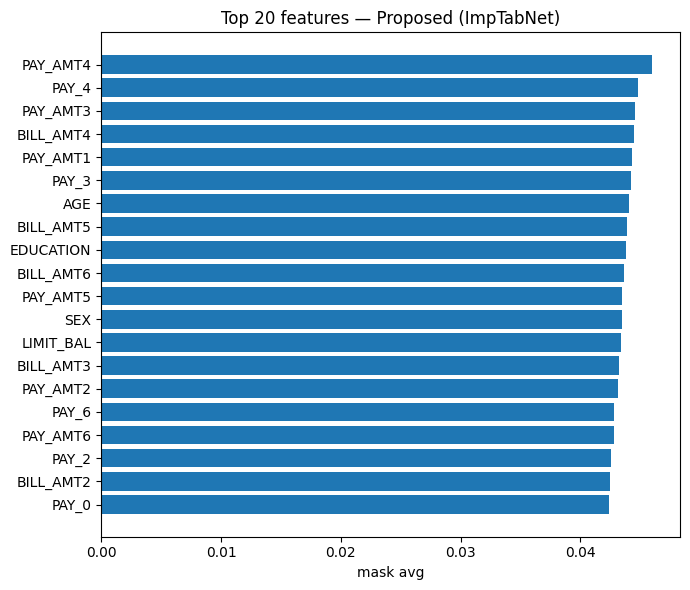

In [43]:
import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# Lấy model thô từ lần train final proposed (k=8, d_emb=8, seed=42)
model = raw            # 'raw' = model trả về từ train_tabnet_be; nếu tên khác, đổi lại
device = dev
model.eval()

@torch.no_grad()
def feature_importance(model, X, device, batch_size=2048):
    """Độ quan trọng = tổng mask qua step, trung bình qua mẫu & qua k sub-model."""
    if hasattr(X, 'values'): X = X.values
    X = X.astype(np.float32)
    agg = None
    n = 0
    for s in range(0, len(X), batch_size):
        xb = torch.tensor(X[s:s+batch_size]).to(device)
        mm = model.get_masks(xb)          # (steps, B, k, F)
        mm = mm.sum(0).mean(1)            # cộng step -> TB qua k -> (B, F)
        b_sum = mm.sum(0).cpu().numpy()   # cộng theo batch
        agg = b_sum if agg is None else agg + b_sum
        n += mm.shape[0]
    imp = agg / n                          # TB qua toàn bộ mẫu -> (F,)
    return imp / imp.sum()                 # chuẩn hoá về tỉ lệ (tổng = 1)

imp = feature_importance(model, X_fe_te_np, device)   # tính trên tập test

df_imp = (pd.DataFrame({'feature': FEAT_NAMES, 'importance': imp})
            .sort_values('importance', ascending=False)
            .reset_index(drop=True))

TOP = 20
# print(df_imp.head(TOP).to_string(index=False))

# Biểu đồ top-N
top = df_imp.head(TOP).iloc[::-1]
plt.figure(figsize=(7, 6))
plt.barh(top['feature'], top['importance'])
plt.xlabel('mask avg')
plt.title(f'Top {TOP} features — Proposed (ImpTabNet)')
plt.tight_layout()
plt.show()

# K - uncertainty

In [44]:
# 1) Train PROPOSED FINAL cho TAIWAN (k=4, d_emb=16) -> biến riêng wrap_prop_tw
final_cfg = {kk: v for kk, v in BASE_CFG.items() if kk not in ('seed', 'd_emb')}
final_cfg.update(best['Proposed'])     # ⚠️ phải là param tune TRÊN TAIWAN
final_cfg['d_emb'] = 16                 # ← TAIWAN: 16

wrap_prop, _, va_m, te_m, *_ = train_tabnet_be(
    X_fe_tr_np, X_fe_va_np, X_fe_te_np,
    y_train, y_valid, y_test, bad_w,
    k=4, use_plr=True, seed=42,          # ← TAIWAN: k=4
    verbose_every=10**9, **final_cfg)

print("Proposed Taiwan -> valid AUC:", round(va_m['auc'],4), "| test AUC:", round(te_m['auc'],4))

# 2) Kiểm uncertainty khác 0
pd_mean, pd_std = wrap_prop.predict_with_uncertainty(X_fe_te_np)
print("std: min=%.5f  median=%.5f  max=%.5f  |  %% std<1e-6: %.1f%%" % (
    pd_std.min(), np.median(pd_std), pd_std.max(), (pd_std<1e-6).mean()*100))

    Epoch   1 | valid_auc=0.69375 | 18s
  [valid] AUC=0.7751  Gini=0.5502  KS=0.4072  F1(bad)=0.5312
  [train] AUC=0.7895  Gini=0.5789  KS=0.4379  F1(bad)=0.5439
  [test] AUC=0.7834  Gini=0.5668  KS=0.4448  F1(bad)=0.5476
  Done 684.0s | Train=0.7895 | Valid=0.7751 | Test=0.7834 | Gap=0.0144
Proposed Taiwan -> valid AUC: 0.7751 | test AUC: 0.7834
std: min=0.00002  median=0.03180  max=0.16192  |  % std<1e-6: 0.0%


In [45]:
from scipy.stats import spearmanr

# Uncertainty từ proposed k=8 trên Taiwan
pd_mean, pd_std = wrap_prop.predict_with_uncertainty(X_fe_te_np)
y_te = np.asarray(y_test)
N    = len(y_te)
err  = np.abs(y_te - pd_mean)          # <-- 'err' được định nghĩa ở đây

# KIỂM std khác 0 (nếu toàn 0 -> nhầm model k=1)
print("std: min=%.5f  median=%.5f  max=%.5f  |  %% std<1e-6: %.1f%%" % (
    pd_std.min(), np.median(pd_std), pd_std.max(), (pd_std<1e-6).mean()*100))

std: min=0.00002  median=0.03180  max=0.16192  |  % std<1e-6: 0.0%


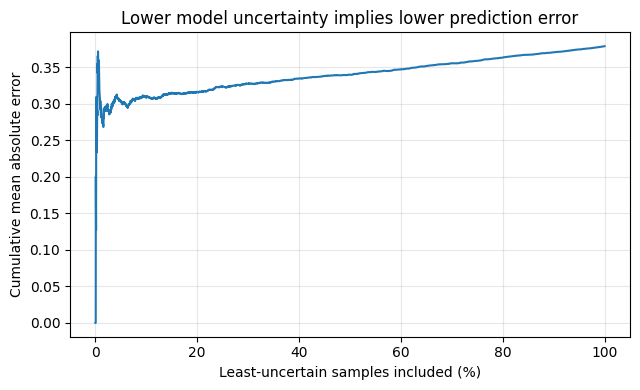

Spearman(uncertainty, error) = 0.292  (p = 1.38e-118)


In [46]:
# Cumulative mean error as we include the least-uncertain samples first
order        = np.argsort(pd_std)
err_sorted   = err[order]
cum_mean_err = np.cumsum(err_sorted) / np.arange(1, N + 1)
frac         = np.arange(1, N + 1) / N

plt.figure(figsize=(6.5, 4))
plt.plot(frac * 100, cum_mean_err, '-')
plt.xlabel('Least-uncertain samples included (%)')
plt.ylabel('Cumulative mean absolute error')
plt.title('Lower model uncertainty implies lower prediction error')
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

# Single-number evidence: rank correlation between uncertainty and error
rho, p_rho = spearmanr(pd_std, err)
print(f"Spearman(uncertainty, error) = {rho:.3f}  (p = {p_rho:.2e})")

 flag_rate  n_auto  AUC_auto
      0.00    6000    0.7834
      0.05    5700    0.7852
      0.10    5400    0.7872
      0.15    5100    0.7885
      0.20    4800    0.7910
      0.25    4500    0.7977
      0.30    4200    0.8011
      0.35    3900    0.8036
      0.40    3600    0.8092
      0.45    3300    0.8134
      0.50    3000    0.8161


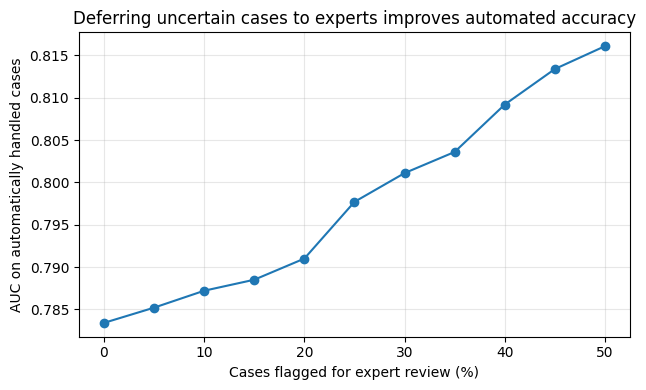

In [47]:
rates = np.arange(0, 0.55, 0.05)          # flag 0% .. 50% (x-axis sweep for the curve)
order = np.argsort(pd_std)                 # ascending uncertainty
curve = []
for r in rates:
    n_flag   = int(round(r * N))           # flag the r% most-uncertain cases
    keep_idx = order[:N - n_flag] if n_flag > 0 else order
    keep = np.zeros(N, bool); keep[keep_idx] = True
    try:
        auc_keep = roc_auc_score(y_te[keep], pd_mean[keep]) if keep.sum() > 50 else np.nan
    except ValueError:
        auc_keep = np.nan
    curve.append({'flag_rate': round(r, 2), 'n_auto': int(keep.sum()),
                  'AUC_auto': round(auc_keep, 4) if auc_keep == auc_keep else np.nan})
df_curve = pd.DataFrame(curve)
print(df_curve.to_string(index=False))

plt.figure(figsize=(6.5, 4))
plt.plot(df_curve['flag_rate'] * 100, df_curve['AUC_auto'], 'o-')
plt.xlabel('Cases flagged for expert review (%)')
plt.ylabel('AUC on automatically handled cases')
plt.title('Deferring uncertain cases to experts improves automated accuracy')
plt.grid(alpha=.3); plt.tight_layout(); plt.show()